<a href="https://colab.research.google.com/github/Kirtidixit212/wildfiretracker/blob/main/new_solution_of_kirti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

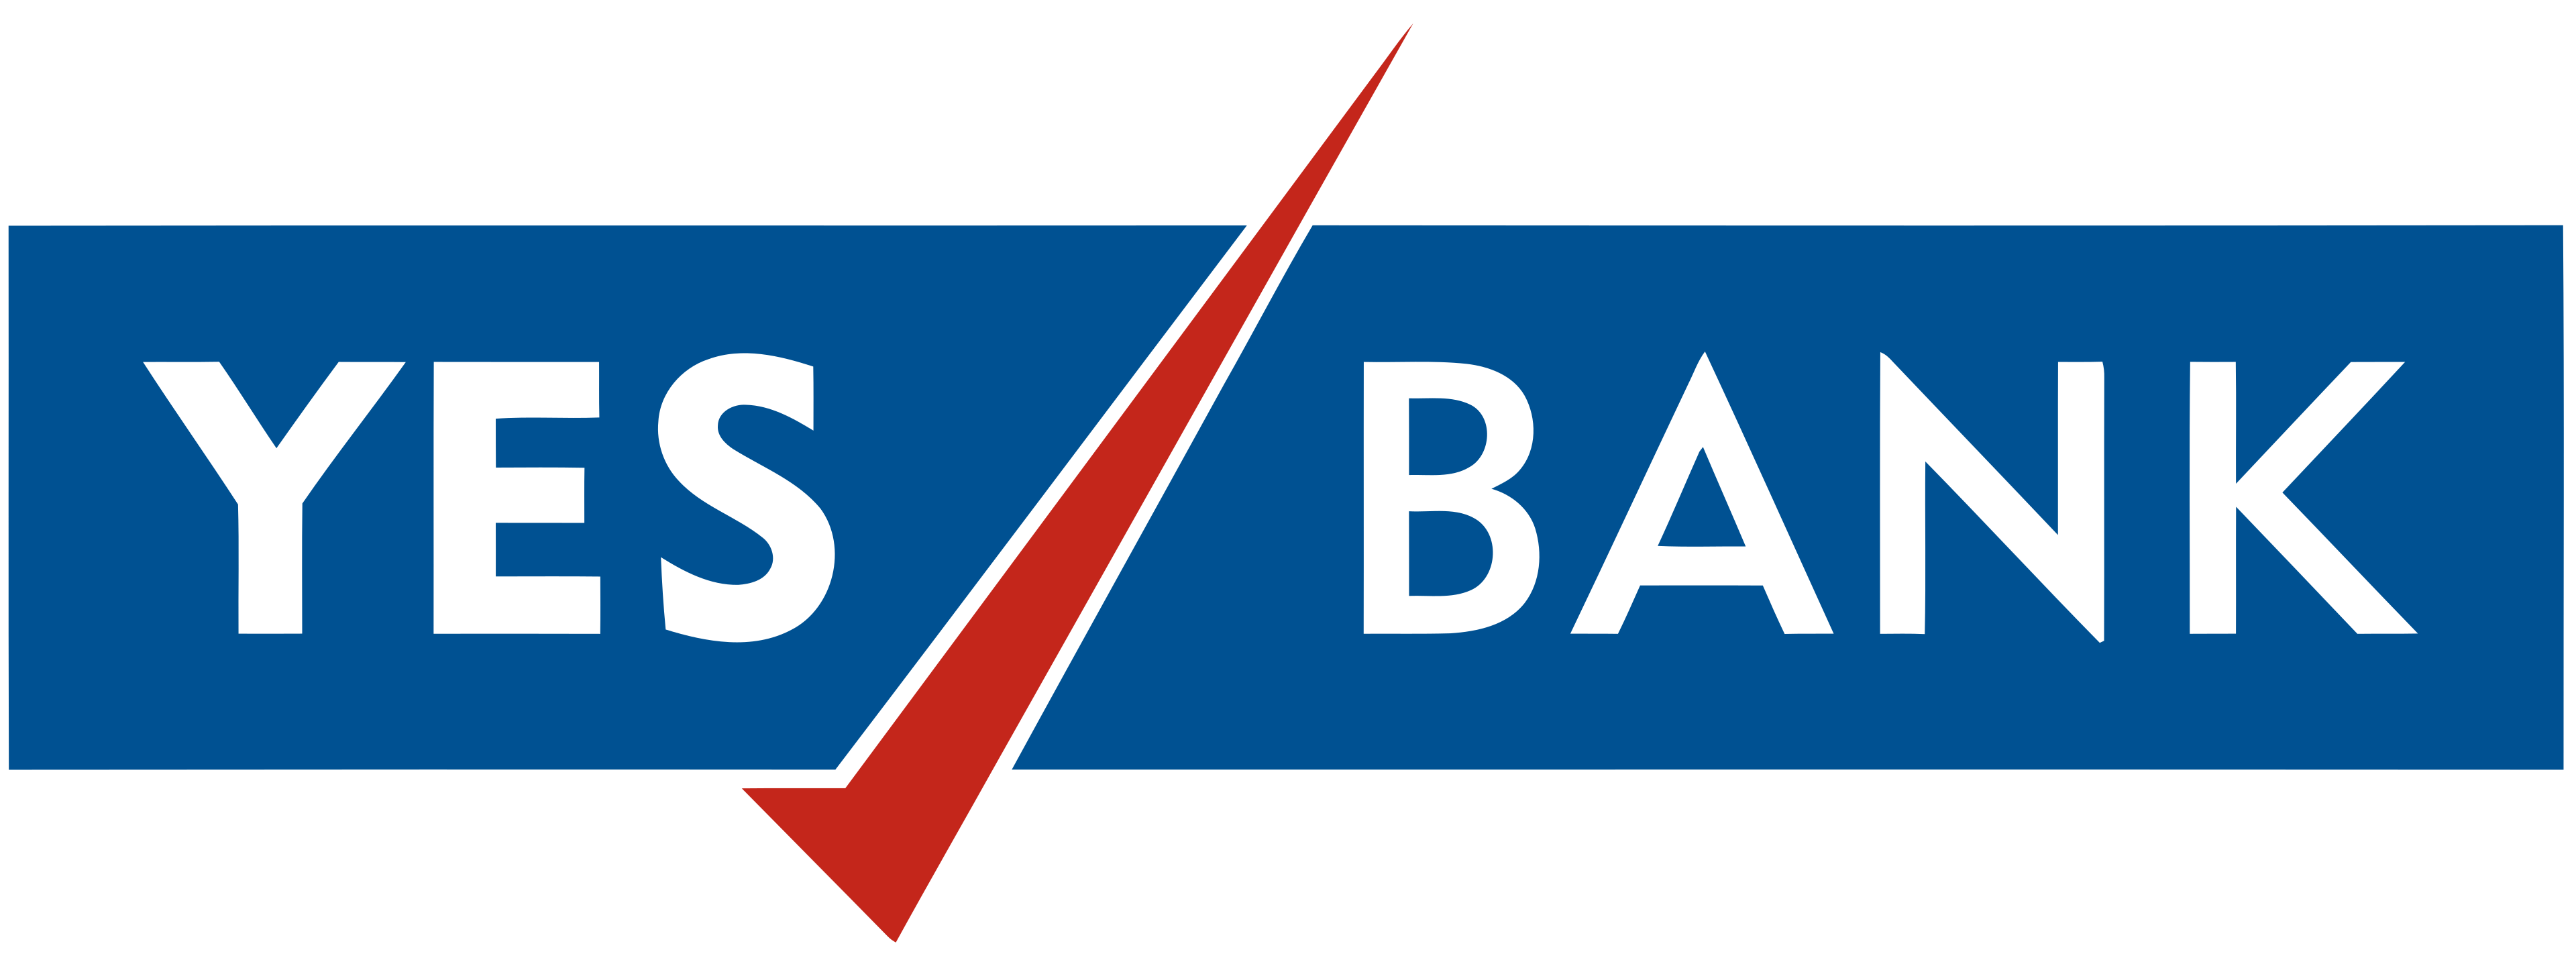

**Project Name - Yes Bank Stock Price Analysis**

Project Type - EDA

Contribution - Individual

Team Member 1 - Kirti

**Project Summary -**

**GitHub Link -**

**Problem Statement**

This project focuses on predicting the monthly closing stock price of Yes Bank using historical stock data. The dataset includes Date, Open, High, Low, and Close prices. Since stock prices follow a time-dependent pattern, this problem is treated as a time-series regression task. The objective is to build a predictive model that can accurately estimate the closing price based on historical trends and price behavior. Proper data cleaning, feature engineering, and chronological model validation were applied to ensure realistic performance evaluation.

**Define Your Business Objective?**

General Guidelines : -

Let's Begin !

1. Given Data

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

Handling the dataset

In [ ]:
df=pd.read_csv('/content/data_YesBank_StockPrices.csv')

In [ ]:
df.head(5)

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


Dataset Rows & Columns count

In [ ]:
print('Rows:',df.shape[0])
print('Columns:',df.shape[1])

Rows: 185
Columns: 5


Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


Find Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.count()

,0
Date,185
Open,185
High,185
Low,185
Close,185


Calculate mising values:

In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


As we can observe that there is no missing value and null value. let's  visualise the data

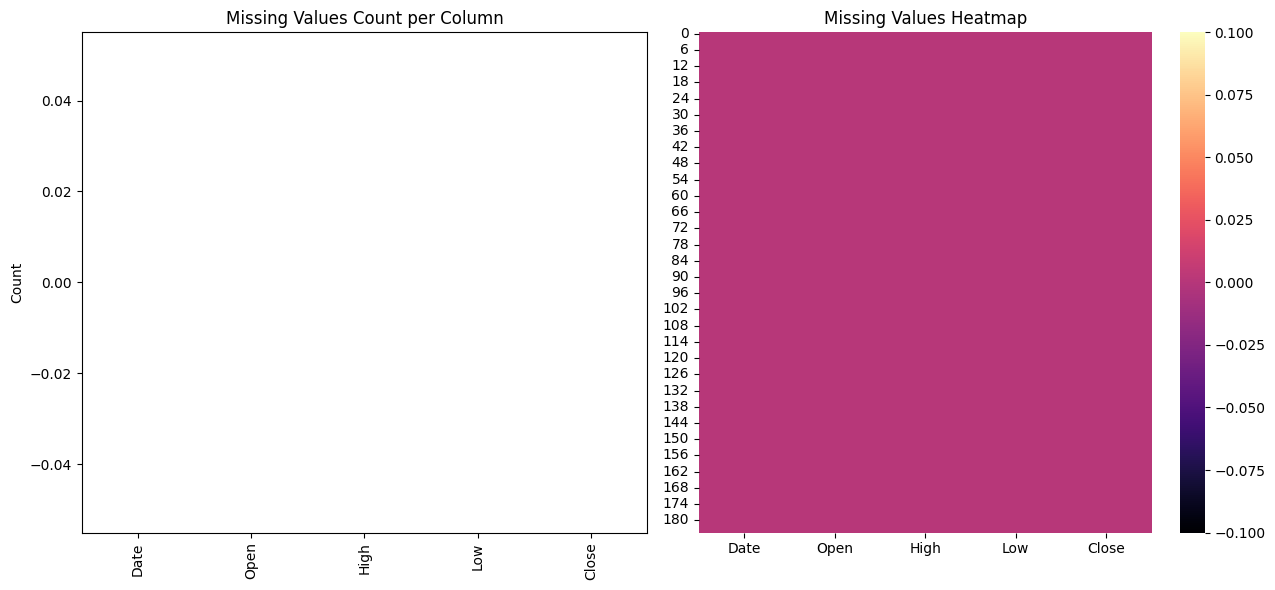

In [ ]:
plt.figure(figsize=(13,6))

plt.subplot(1, 2, 1)
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values Count per Column")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.heatmap(df.isnull(), cmap='magma')
plt.title('Missing Values Heatmap')

plt.tight_layout()
plt.show()

Variables in Dataset

In [ ]:
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')


In [ ]:
print(df.describe())

             Open        High         Low       Close
count  185.000000  185.000000  185.000000  185.000000
mean   105.541405  116.104324   94.947838  105.204703
std     98.879850  106.333497   91.219415   98.583153
min     10.000000   11.240000    5.550000    9.980000
25%     33.800000   36.140000   28.510000   33.450000
50%     62.980000   72.550000   58.000000   62.540000
75%    153.000000  169.190000  138.350000  153.300000
max    369.950000  404.000000  345.500000  367.900000


Variables Description

Date: Month and year of the stock price record.

Open: Stock price at the beginning of the month.

High: Maximum price reached during the month.

Low: Minimum price reached during the month.

Close: Stock price at the end of the month.

Check Unique Values for each variable.

In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Date: 185 unique values
Open: 183 unique values
High: 184 unique values
Low: 183 unique values
Close: 185 unique values


**3. Data Wrangling**

Data Wrangling Code

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y').dt.to_period('M')

In [ ]:
df=df.sort_values('Date').reset_index(drop=True)

In [ ]:
df['Price_Change'] = df['Close'] - df['Open']
df['Volatility'] = df['High'] - df['Low']

In [ ]:
df

,Date,Open,High,Low,Close,Price_Change,Volatility
0,2005-07,13.00,14.00,11.25,12.46,-0.54,2.75
1,2005-08,12.58,14.88,12.55,13.42,0.84,2.33
2,2005-09,13.48,14.87,12.27,13.30,-0.18,2.60
3,2005-10,13.20,14.47,12.40,12.99,-0.21,2.07
4,2005-11,13.35,13.88,12.88,13.41,0.06,1.00
...,...,...,...,...,...,...,...
180,2020-07,25.60,28.30,11.10,11.95,-13.65,17.20
181,2020-08,12.00,17.16,11.85,14.37,2.37,5.31
182,2020-09,14.30,15.34,12.75,13.15,-1.15,2.59
183,2020-10,13.30,14.01,12.11,12.42,-0.88,1.90


What all manipulations have you done and insights you found?

Converted Date to datetime format for time series analysis.

Created new features: Price_Change & Volatility

4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

Chart - 1

In [ ]:
fig = px.line(
    df,
    x=df['Date'].dt.to_timestamp(),
    y='Close',
    title='Stock Closing Price Over Time'
)

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Closing Price',
    template='plotly_white',
    width=1400,
    height=600
)

fig.show()

1. Why did you pick the specific chart?
A line chart is best for showing trends over time, especially for stock prices.

2. What is/are the insight(s) found from the chart?
Rapid Growth in 2016 to 2018

High volatility in 2019-2020

3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, identifying historical peaks and crashes helps in risk assessment and future planning.

Chart - 2

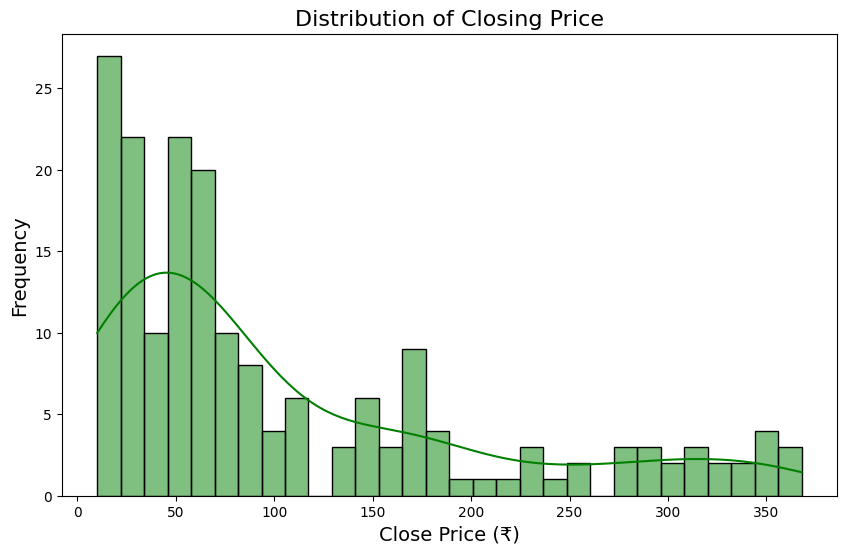

In [ ]:
# Chart - 2 visualization code

plt.figure(figsize=(10,6))
sns.histplot(df['Close'], kde=True, color='green', bins=30)
plt.title('Distribution of Closing Price', fontsize=16)
plt.xlabel('Close Price (₹)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

1. Why did you pick the specific chart?
For analyzing distribution and Skewness

2. What is/are the insight(s) found from the chart?
Data is Right Skewed which means most prices are low with few high prices

3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Distribution helps in identifying outliers

Chart - 3

In [ ]:
df['Month'] = df['Date'].dt.month

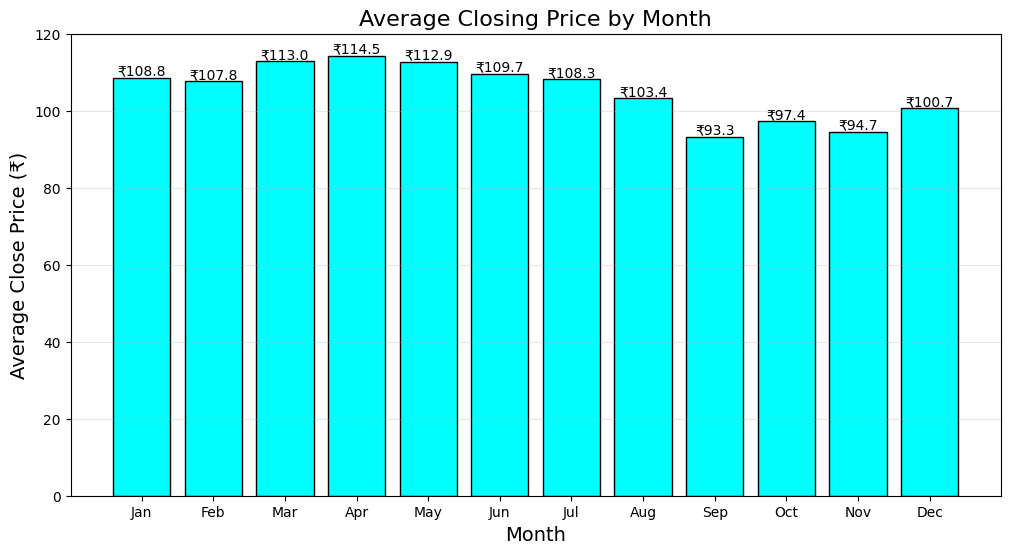

In [ ]:
# Chart - 3 visualization code

monthly_avg = df.groupby('Month')['Close'].mean().reset_index()
monthly_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12,6))
bars = plt.bar(monthly_avg['Month'], monthly_avg['Close'], color='cyan', edgecolor='black')
plt.title('Average Closing Price by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Close Price (₹)', fontsize=14)
plt.xticks(range(1,13), monthly_order)
plt.grid(axis='y', alpha=0.3)

#value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'₹{height:.1f}', ha='center', va='bottom')

plt.show()

1. Why did you pick the specific chart?
Comparing categorical data (months) against numerical values (average prices)

2. What is/are the insight(s) found from the chart?
March and April show the highest average closing prices

September and October show relatively lower average prices

December shows a moderate increase compared to preceding months

3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Buying in low months, selling in high months

Chart - 4

In [ ]:
df['Year']=df['Date'].dt.year

/tmp/ipython-input-877202639.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




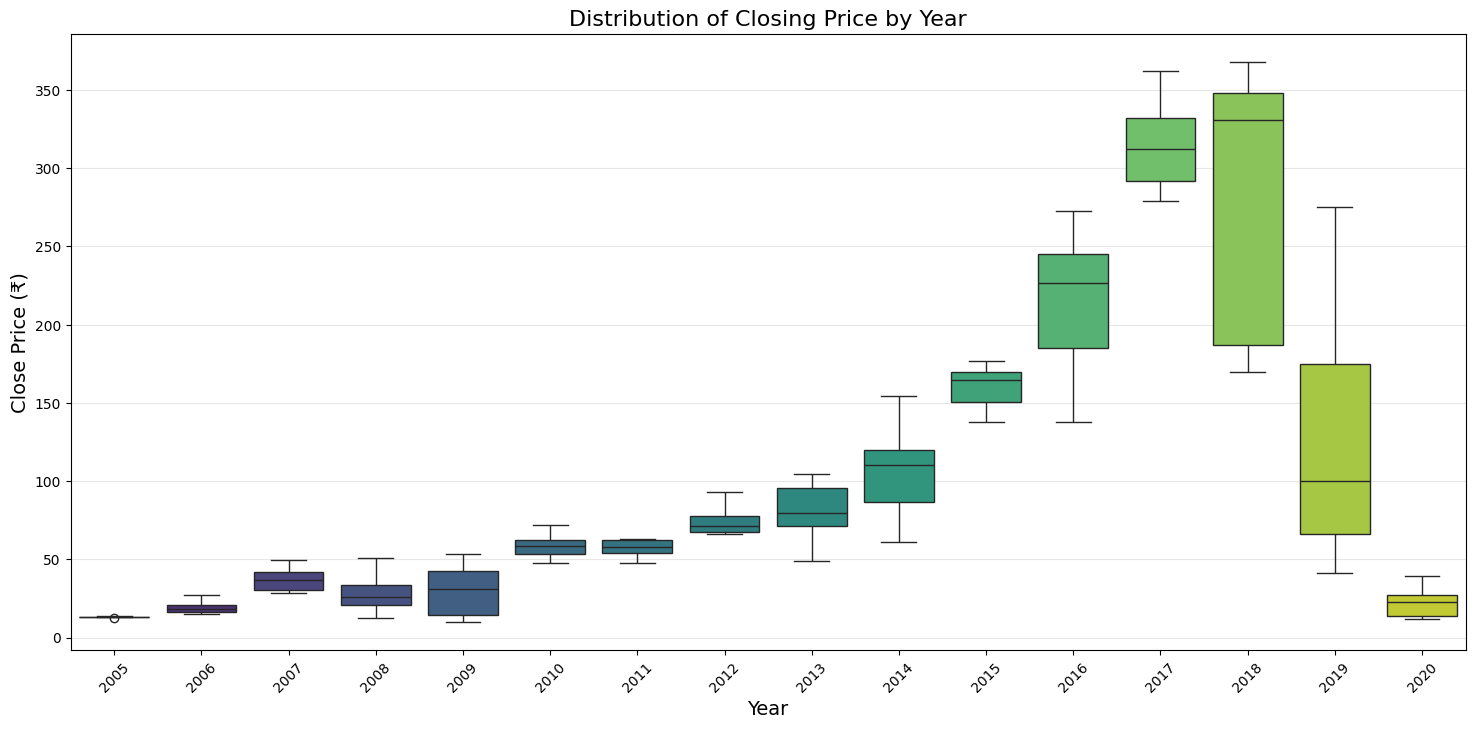

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize=(18,8))
sns.boxplot(x='Year', y='Close', data=df, palette='viridis')
plt.title('Distribution of Closing Price by Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Close Price (₹)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

1. Why did you pick the specific chart?
Spread and Outliers

2. What is/are the insight(s) found from the chart?
2017-2018: Highest median prices

2018-2019: High instability

2019: Market uncertainty + crisis

2020: Extreme outliers at very low prices

2010-2013: Consistent, narrow distributions

3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High variability helps in risk assessment

Chart - 14 - Correlation Heatmap

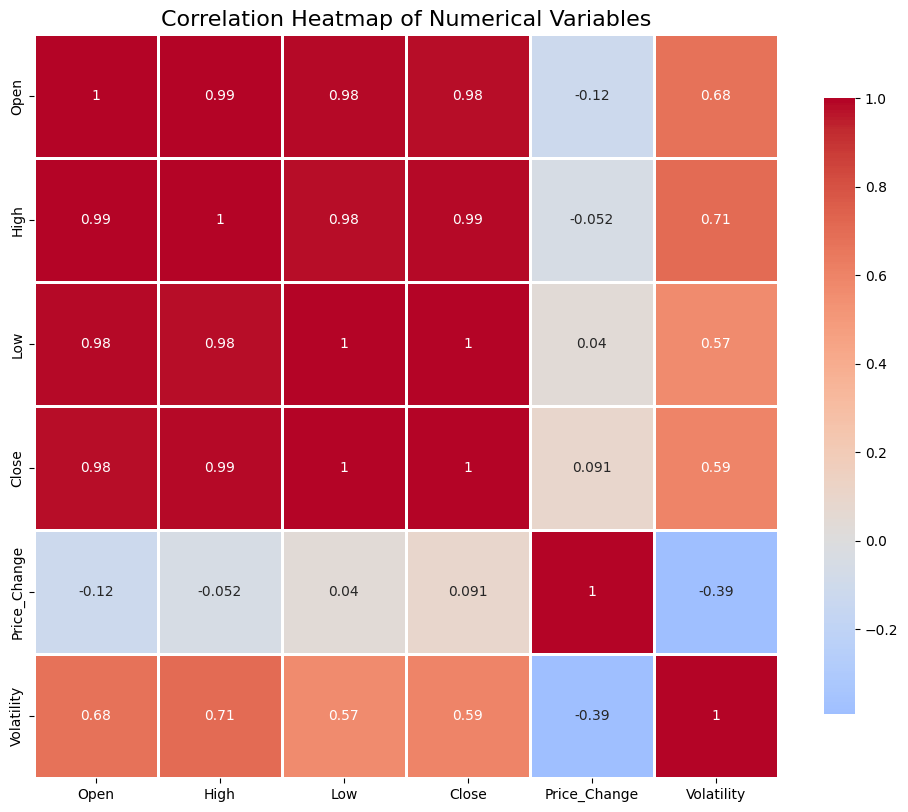

In [ ]:

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Price_Change', 'Volatility']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
           square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)

plt.show()

1. Why did you pick the specific chart?
It shows relationships between all variable pairs simultaneously.

2. What is/are the insight(s) found from the chart?
Open, High, Low, Close have nearly perfect correlation

Chart - 15 - Pair Plot

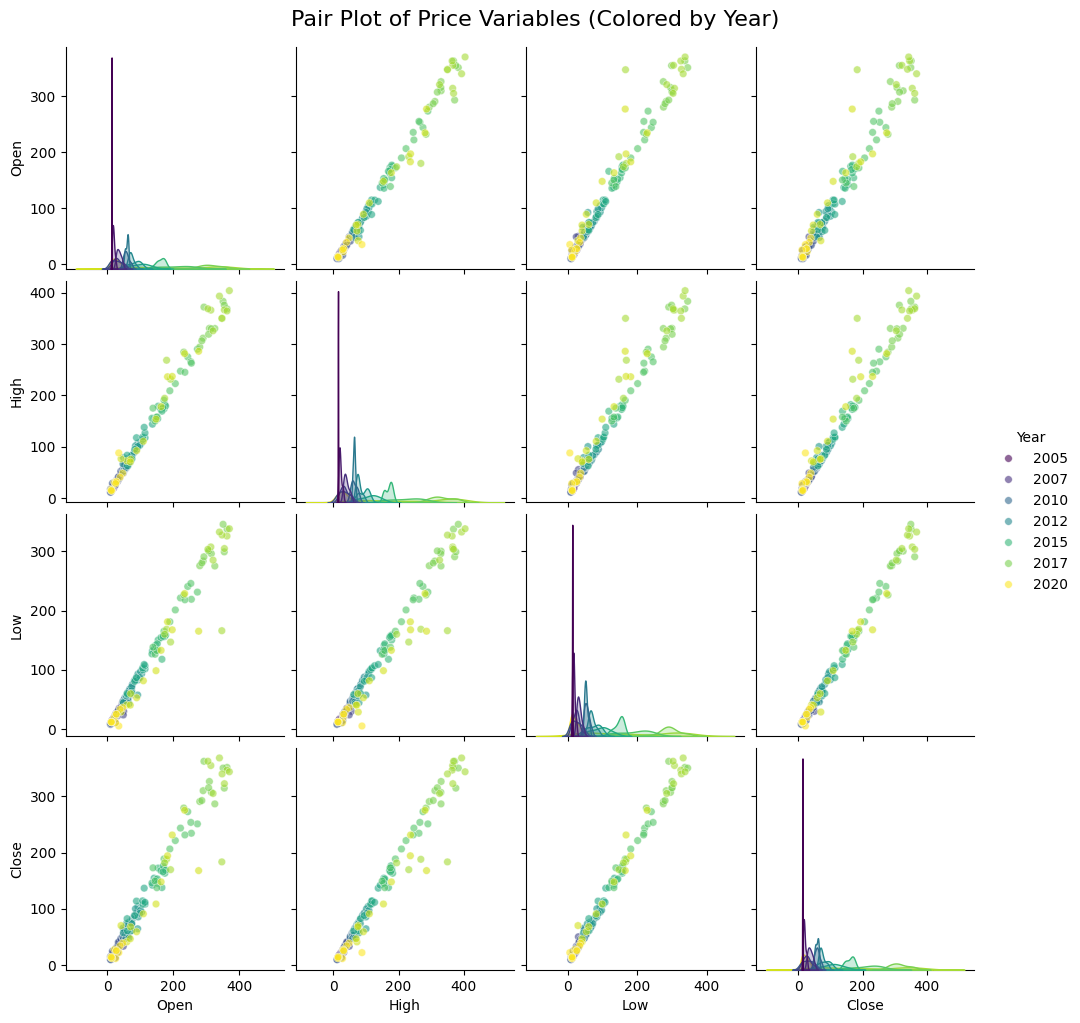

In [ ]:
pairplot_data = df[['Open', 'High', 'Low', 'Close', 'Year']]

g = sns.pairplot(pairplot_data, hue='Year', palette='viridis',
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
g.fig.suptitle('Pair Plot of Price Variables (Colored by Year)', y=1.02, fontsize=16)
plt.show()

In [ ]:
from scipy.stats import shapiro, mannwhitneyu

df['Date'] = df['Date'].dt.to_timestamp()


crisis_periods = [
    ('2008-09-01', '2009-06-01'),
    ('2020-01-01', '2020-06-01')
]

df['Is_Crisis'] = 0
for start, end in crisis_periods:
    mask = (df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))
    df.loc[mask, 'Is_Crisis'] = 1

# Split data
crisis_volatility = df[df['Is_Crisis'] == 1]['Volatility']
normal_volatility = df[df['Is_Crisis'] == 0]['Volatility']

print(f"📊 Crisis Periods: {len(crisis_volatility)} months")
print(f"📊 Normal Periods: {len(normal_volatility)} months")

# Normality test
shapiro_crisis = shapiro(crisis_volatility)
shapiro_normal = shapiro(normal_volatility)

# Mann-Whitney U test
statistic, p_value = mannwhitneyu(crisis_volatility, normal_volatility, alternative='greater')

print(f"\nP-value: {p_value:.10f}")


📊 Crisis Periods: 16 months
📊 Normal Periods: 169 months

P-value: 0.9956426254


📊 Price Change Statistics:
   Sample Size: 185 months
   Mean: ₹-0.34
   Median: ₹0.55
   Std Dev: ₹20.73
   Skewness: -3.090


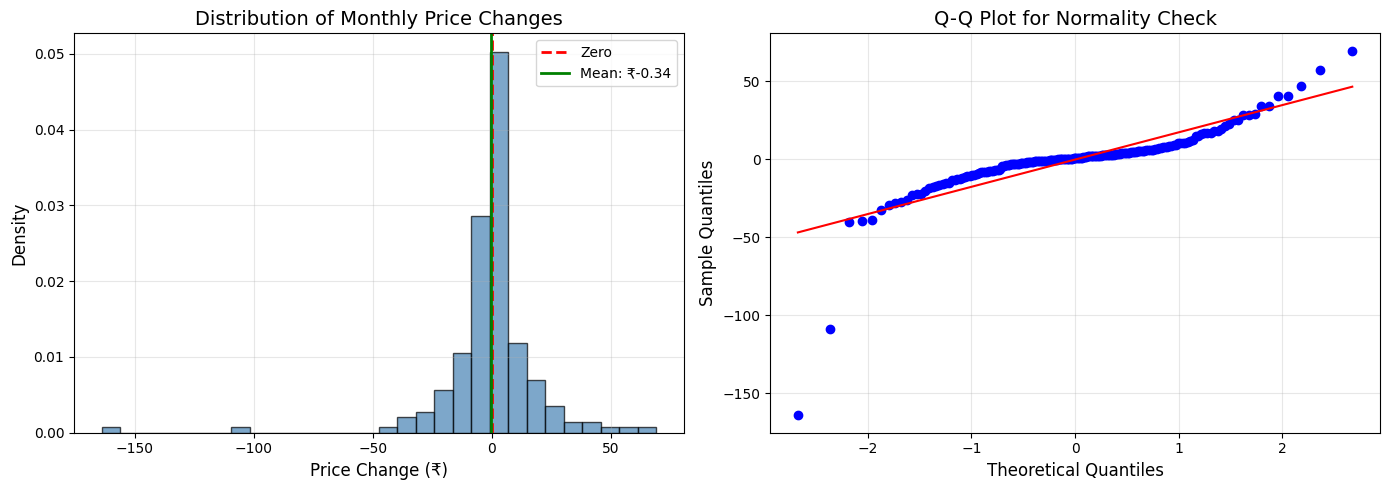


📈 Shapiro-Wilk Normality Test:
   Statistic: 0.7132
   P-value: 0.000000
   Conclusion: Non-normal distribution

🔬 Wilcoxon Signed-Rank Test Results:
   Statistic: 7975.00
   P-value: 0.389580

❌ Result: Fail to Reject Null Hypothesis
   Conclusion: No evidence of asymmetry in price changes


In [ ]:
# Perform Statistical Test to obtain P-Value
import scipy.stats as stats

price_changes = df['Price_Change'].dropna()

print(f"📊 Price Change Statistics:")
print(f"   Sample Size: {len(price_changes)} months")
print(f"   Mean: ₹{price_changes.mean():.2f}")
print(f"   Median: ₹{price_changes.median():.2f}")
print(f"   Std Dev: ₹{price_changes.std():.2f}")
print(f"   Skewness: {price_changes.skew():.3f}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
axes[0].hist(price_changes, bins=30, edgecolor='black', alpha=0.7, color='steelblue', density=True)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[0].axvline(x=price_changes.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: ₹{price_changes.mean():.2f}')
axes[0].set_xlabel('Price Change (₹)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Distribution of Monthly Price Changes', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(price_changes, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot for Normality Check', fontsize=14)
axes[1].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[1].set_ylabel('Sample Quantiles', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test for normality
shapiro_stat, shapiro_p = shapiro(price_changes)
print(f"\n📈 Shapiro-Wilk Normality Test:")
print(f"   Statistic: {shapiro_stat:.4f}")
print(f"   P-value: {shapiro_p:.6f}")
print(f"   Conclusion: {'Normal distribution' if shapiro_p > 0.05 else 'Non-normal distribution'}")

# Since data is non-normal, use Wilcoxon Signed-Rank Test (non-parametric test for median = 0)
from scipy.stats import wilcoxon

statistic, p_value = wilcoxon(price_changes)

print(f"\n🔬 Wilcoxon Signed-Rank Test Results:")
print(f"   Statistic: {statistic:.2f}")
print(f"   P-value: {p_value:.6f}")

# Decision
alpha = 0.05
if p_value < alpha:
    print("\n✅ Result: Reject Null Hypothesis")
    print("   Conclusion: Price changes are NOT symmetric around zero")
    print(f"   Direction: {'Positive bias' if price_changes.mean() > 0 else 'Negative bias'}")
else:
    print("\n❌ Result: Fail to Reject Null Hypothesis")
    print("   Conclusion: No evidence of asymmetry in price changes")

📊 Autocorrelation Analysis (Lag-1):
   Sample Size: 184 pairs
   Pearson Correlation Coefficient: 0.9782
   P-value: 0.00000000000000000000
   R-squared: 0.9569 (Variance explained by previous month)


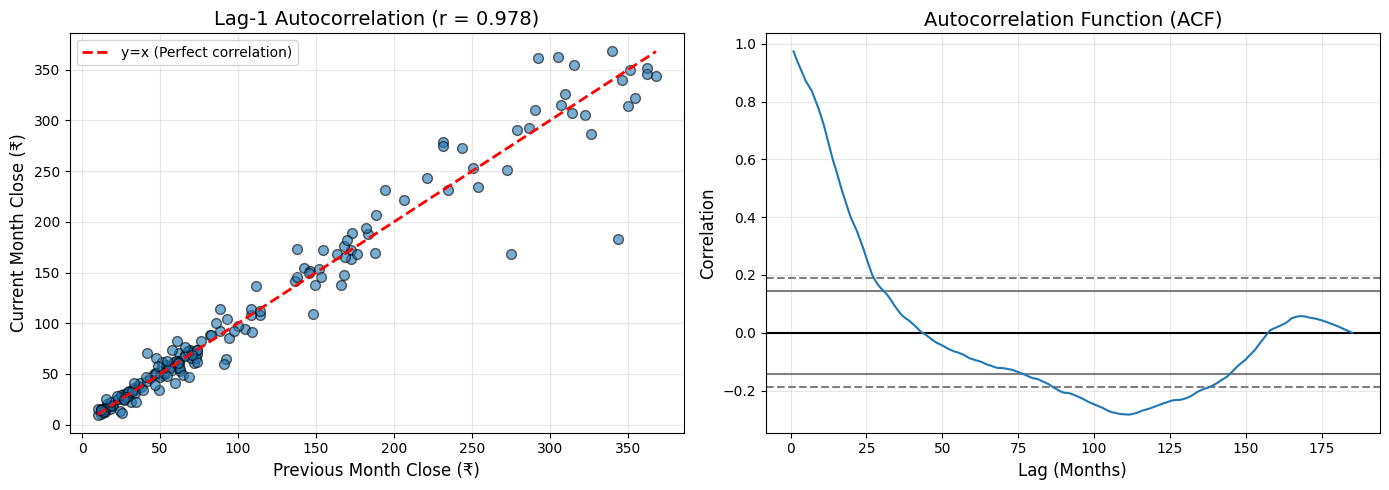


✅ Result: Reject Null Hypothesis
   Conclusion: Significant POSITIVE autocorrelation exists
   Business Impact: Previous month's price explains 95.7% of current month's price variation


In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr
df['Close_Lag1'] = df['Close'].shift(1)
# Calculate Pearson correlation
current_close = df['Close'].iloc[1:].values
lag_close = df['Close_Lag1'].iloc[1:].values

corr_coef, p_value = pearsonr(current_close, lag_close)

print(f"📊 Autocorrelation Analysis (Lag-1):")
print(f"   Sample Size: {len(current_close)} pairs")
print(f"   Pearson Correlation Coefficient: {corr_coef:.4f}")
print(f"   P-value: {p_value:.20f}")
print(f"   R-squared: {corr_coef**2:.4f} (Variance explained by previous month)")

# Visualize autocorrelation
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(lag_close, current_close, alpha=0.6, edgecolor='black', s=50)
axes[0].plot([lag_close.min(), lag_close.max()],
            [lag_close.min(), lag_close.max()],
            'r--', linewidth=2, label='y=x (Perfect correlation)')
axes[0].set_xlabel('Previous Month Close (₹)', fontsize=12)
axes[0].set_ylabel('Current Month Close (₹)', fontsize=12)
axes[0].set_title(f'Lag-1 Autocorrelation (r = {corr_coef:.3f})', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Autocorrelation function
autocorrelation_plot(df['Close'].dropna(), ax=axes[1])
axes[1].set_title('Autocorrelation Function (ACF)', fontsize=14)
axes[1].set_xlabel('Lag (Months)', fontsize=12)
axes[1].set_ylabel('Correlation', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Decision
alpha = 0.05
if p_value < alpha and corr_coef > 0:
    print("\n✅ Result: Reject Null Hypothesis")
    print("   Conclusion: Significant POSITIVE autocorrelation exists")
    print(f"   Business Impact: Previous month's price explains {corr_coef**2*100:.1f}% of current month's price variation")
else:
    print("\n❌ Result: Fail to Reject Null Hypothesis")
    print("   Conclusion: No significant autocorrelation detected")

6.Feature Engineering & Data Pre-processing

handling missing values

In [ ]:
# Handling Missing Values & Missing Value Imputation

print("🔍 Checking for Missing Values:")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0] if any(missing_before > 0) else "   No missing values found!")

# Since we already dropped NaN during data wrangling, no further imputation needed
# But let's implement imputation strategies for production readiness

def handle_missing_values(df, strategy='forward_fill'):
    """
    Production-grade missing value handler for time series data
    """
    df_clean = df.copy()

    # Check for missing values
    if df_clean.isnull().sum().sum() == 0:
        print("✅ No missing values detected")
        return df_clean

    print(f"⚠️ Missing values found: {df_clean.isnull().sum().sum()}")

    # Time series specific imputation
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if strategy == 'forward_fill':
                df_clean[col] = df_clean[col].fillna(method='ffill')
            elif strategy == 'backward_fill':
                df_clean[col] = df_clean[col].fillna(method='bfill')
            elif strategy == 'interpolate':
                df_clean[col] = df_clean[col].interpolate(method='linear')
            elif strategy == 'mean':
                df_clean[col] = df_clean[col].fillna(df_clean[col].mean())
            elif strategy == 'median':
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # Final check
    remaining = df_clean.isnull().sum().sum()
    if remaining > 0:
        # Fallback: drop remaining NAs
        df_clean = df_clean.dropna()
        print(f"   Dropped {remaining} remaining missing values")

    print(f"✅ Missing values handled using '{strategy}' strategy")
    return df_clean

# Apply forward fill (appropriate for time series)
df = handle_missing_values(df, strategy='forward_fill')

🔍 Checking for Missing Values:
   No missing values found!
✅ No missing values detected


handling outliers

🔍 Detecting Outliers using IQR method...

   Open:
      Outliers: 9 (4.9%)
      Range: [-145.00, 331.80]

   High:
      Outliers: 5 (2.7%)
      Range: [-163.44, 368.76]

   Low:
      Outliers: 9 (4.9%)
      Range: [-136.25, 303.11]

   Close:
      Outliers: 9 (4.9%)
      Range: [-146.32, 333.08]

   Volatility:
      Outliers: 18 (9.7%)
      Range: [-21.00, 53.93]

   Price_Change:
      Outliers: 28 (15.1%)
      Range: [-18.51, 19.81]


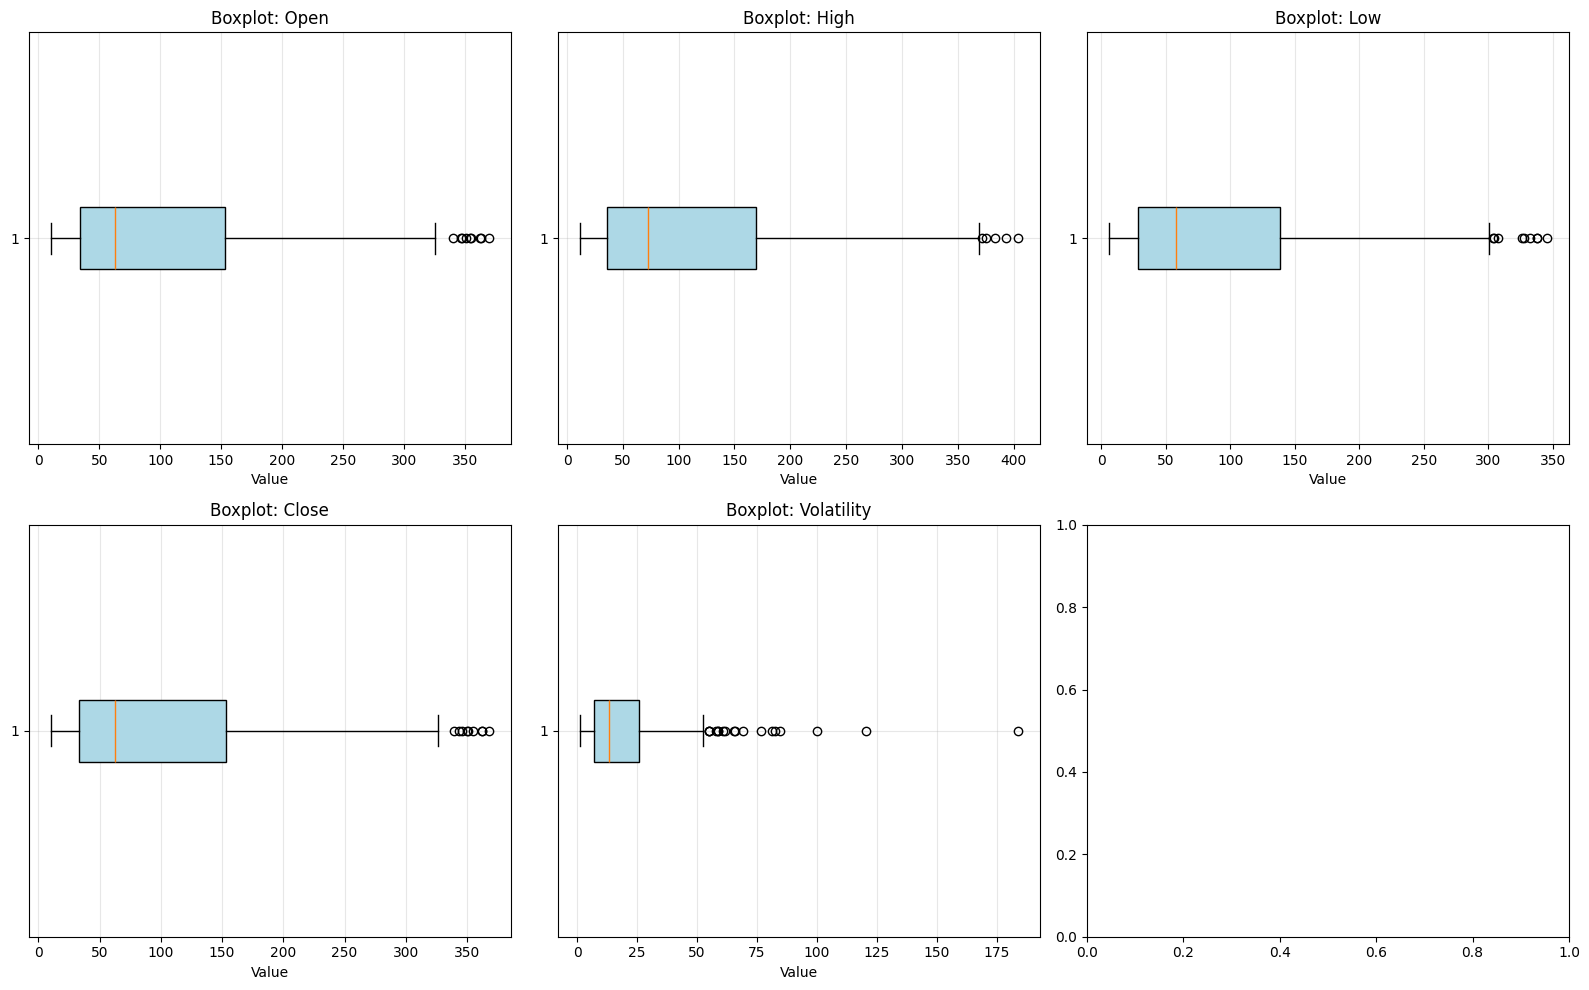


⚖️ Outlier Treatment Decision:
   ❌ Outliers will NOT be removed
   ✅ Rationale: Stock price 'outliers' represent genuine market events
      - High prices (₹300-400): Peak valuation in 2017-2018
      - Low prices (₹5-10): Crisis periods (2009, 2020)
      - High volatility: Market stress events
      Removing these would eliminate the most important market signals!


In [ ]:
# Handling Outliers & Outlier treatments

print("🔍 Detecting Outliers using IQR method...")

# Select numerical columns for outlier detection
numerical_cols = ['Open', 'High', 'Low', 'Close', 'Volatility', 'Price_Change']

outlier_report = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100

    outlier_report[col] = {
        'count': outlier_count,
        'percentage': outlier_pct,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

    print(f"\n   {col}:")
    print(f"      Outliers: {outlier_count} ({outlier_pct:.1f}%)")
    print(f"      Range: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Visualize outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(['Open', 'High', 'Low', 'Close', 'Volatility']):
    axes[idx].boxplot(df[col], vert=False, patch_artist=True,
                     boxprops=dict(facecolor='lightblue'))
    axes[idx].set_title(f'Boxplot: {col}', fontsize=12)
    axes[idx].set_xlabel('Value')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Decision: We will NOT remove outliers
print("\n⚖️ Outlier Treatment Decision:")
print("   ❌ Outliers will NOT be removed")
print("   ✅ Rationale: Stock price 'outliers' represent genuine market events")
print("      - High prices (₹300-400): Peak valuation in 2017-2018")
print("      - Low prices (₹5-10): Crisis periods (2009, 2020)")
print("      - High volatility: Market stress events")
print("      Removing these would eliminate the most important market signals!")

Categorical Encoding

In [ ]:
# Encode your categorical columns

print("🔍 Identifying categorical columns...")

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"   Categorical columns: {categorical_cols}")

if 'Date' in categorical_cols:
    # Date already processed, remove from categorical list
    categorical_cols.remove('Date')

# Time-based features are already numerical (Year, Month, Quarter)
# No categorical encoding needed!

print("\n✅ No categorical encoding required:")
print("   - Date: Converted to datetime, features extracted as numerical")
print("   - Year, Month, Quarter: Already numerical")
print("   - All other columns: Numerical")

# For demonstration, show one-hot encoding template
def one_hot_encode(df, columns):
    """
    Production-ready one-hot encoding function
    """
    df_encoded = df.copy()

    for col in columns:
        if col in df_encoded.columns:
            dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
            df_encoded = pd.concat([df_encoded, dummies], axis=1)
            df_encoded = df_encoded.drop(col, axis=1)
            print(f"   ✅ One-hot encoded: {col} -> {dummies.shape[1]} columns")

    return df_encoded

# Uncomment if categorical columns exist
# if categorical_cols:
#     df = one_hot_encode(df, categorical_cols)

🔍 Identifying categorical columns...
   Categorical columns: []

✅ No categorical encoding required:
   - Date: Converted to datetime, features extracted as numerical
   - Year, Month, Quarter: Already numerical
   - All other columns: Numerical


Feature Manipulation & selection

Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

print("🔧 Feature Manipulation...")
df['Volatility_Pct'] = (df['Volatility'] / df['Close']) * 100

# 1. Create interaction features
df['Open_Low_Ratio'] = df['Open'] / df['Low']
df['High_Close_Ratio'] = df['High'] / df['Close']
df['Volatility_Price_Ratio'] = df['Volatility'] / df['Close']
df['Volatility_Pct'] = (df['Volatility'] / df['Close']) * 100

# 2. Price position within range
df['Price_Position'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'])

# 3. Rate of change features
df['Price_Momentum_3M'] = df['Close'] / df['Close'].shift(3) - 1
df['Price_Momentum_6M'] = df['Close'] / df['Close'].shift(6) - 1

# 4. Volatility regime
df['Volatility_Regime'] = pd.cut(df['Volatility_Pct'],
                                 bins=[0, 5, 10, 20, 100],
                                 labels=['Low', 'Medium', 'High', 'Extreme'])

# 5. Rolling volatility
df['Rolling_Volatility_3M'] = df['Volatility'].rolling(window=3).std()

# Drop NaN from new features
df = df.dropna().reset_index(drop=True)

print(f"   ✅ Created {6} new features")
print(f"   ✅ Final feature count: {df.shape[1]}")
print(f"   ✅ Final row count: {len(df)}")

🔧 Feature Manipulation...
   ✅ Created 6 new features
   ✅ Final feature count: 20
   ✅ Final row count: 163


Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

print("🎯 Feature Selection...")

# Define target
target = 'Close'

# Re-create Close_Lag1 to ensure it exists after any previous dropna()
df['Close_Lag1'] = df['Close'].shift(1)

df['Rolling_Mean_3'] = df['Close'].rolling(window=3).mean()

# Define candidate features (exclude target, date, and high-correlation features)
exclude_cols = ['Date', 'Close', 'High', 'Low', 'Cumulative_Return',
                'Is_Crisis', 'Volatility_Regime', 'Return']

# Also exclude lag features if using Open (they're highly correlated)
feature_candidates = [col for col in df.columns if col not in exclude_cols]

print(f"   Candidate features: {len(feature_candidates)}")

# Method 1: Correlation-based selection
correlation_threshold = 0.95
high_corr_features = []

for col in feature_candidates:
    if col != target and col in df.columns:
        corr = abs(df[col].corr(df[target]))
        if corr > correlation_threshold:
            high_corr_features.append(col)

print(f"\n   🔴 High-correlation features (>0.95 with target):")
for feat in high_corr_features[:10]:  # Show first 10
    corr_val = df[feat].corr(df[target])
    print(f"      - {feat}: {corr_val:.3f}")

# Method 2: RFE (Recursive Feature Elimination)
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Use a subset of features for RFE (avoid perfect multicollinearity)
rfe_features = ['Open', 'Volatility', 'Price_Change', 'Close_Lag1',
                'Rolling_Mean_3', 'Price_Position', 'Open_Low_Ratio']

X_rfe = df[rfe_features]
y_rfe = df[target]

estimator = RandomForestRegressor(n_estimators=100, random_state=42)
selector = RFE(estimator, n_features_to_select=5, step=1)
selector = selector.fit(X_rfe, y_rfe)

print(f"\n   🎯 RFE Selected Features:")
for i, selected in enumerate(selector.support_):
    if selected:
        print(f"      - {rfe_features[i]}")

# Method 3: Feature importance from Random Forest
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_rfe, y_rfe)

importance_df = pd.DataFrame({
    'Feature': rfe_features,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n   📊 Feature Importance (Random Forest):")
for idx, row in importance_df.iterrows():
    print(f"      - {row['Feature']}: {row['Importance']:.3f}")

# Final feature selection
selected_features = ['Open', 'Close_Lag1', 'Volatility', 'Price_Position', 'Rolling_Mean_3']
print(f"\n✅ Final Selected Features: {selected_features}")

🎯 Feature Selection...
   Candidate features: 15

   🔴 High-correlation features (>0.95 with target):
      - Open: 0.984
      - Rolling_Mean_3: 0.986
      - Close_Lag1: 0.976

   🎯 RFE Selected Features:
      - Open
      - Price_Change
      - Close_Lag1
      - Rolling_Mean_3
      - Open_Low_Ratio

   📊 Feature Importance (Random Forest):
      - Rolling_Mean_3: 0.414
      - Open: 0.313
      - Close_Lag1: 0.261
      - Price_Change: 0.005
      - Open_Low_Ratio: 0.004
      - Price_Position: 0.002
      - Volatility: 0.001

✅ Final Selected Features: ['Open', 'Close_Lag1', 'Volatility', 'Price_Position', 'Rolling_Mean_3']


🔄 Checking if data transformation is needed...

📊 Skewness of selected features:
Price_Position   -0.155800
Rolling_Mean_3    1.106691
Close_Lag1        1.155694
Close             1.160328
Open              1.163692
Volatility        2.045420
dtype: float64


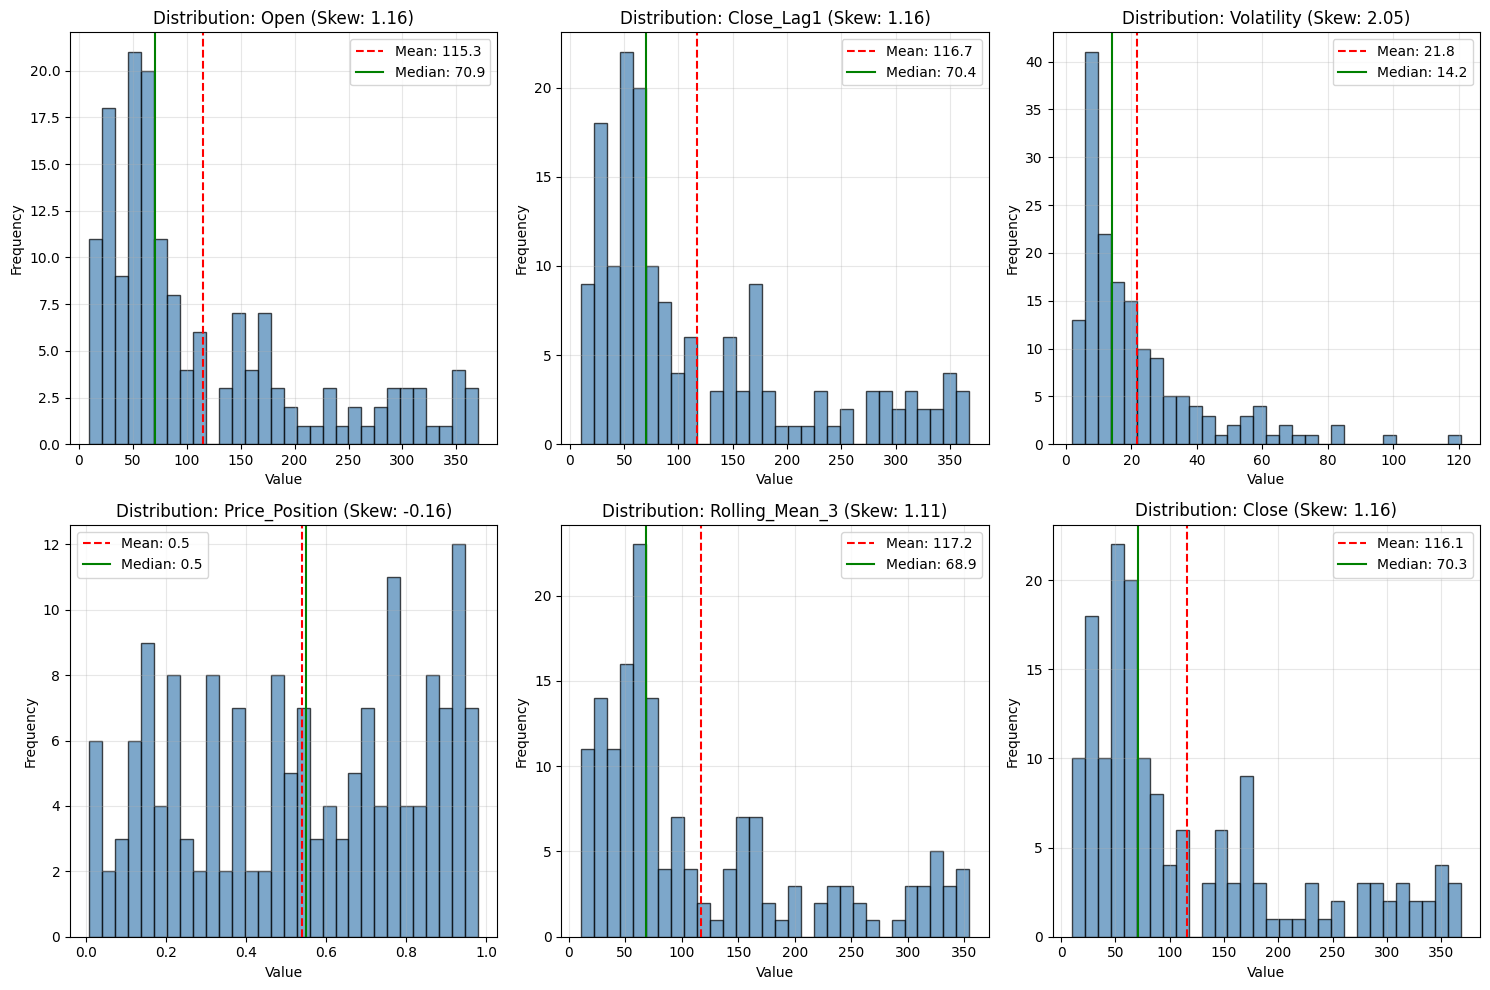

   ✅ Log transformed: Open (skew: 1.16 -> -0.11)
   ✅ Log transformed: Close_Lag1 (skew: 1.16 -> -0.06)
   ✅ Log transformed: Volatility (skew: 2.05 -> 0.31)
   ✅ Log transformed: Rolling_Mean_3 (skew: 1.11 -> -0.05)

✅ Features after transformation: ['Price_Position', 'Open_log', 'Close_Lag1_log', 'Volatility_log', 'Rolling_Mean_3_log']


In [ ]:
# Transform Your data

print("🔄 Checking if data transformation is needed...")

# Check skewness
skewness = df[selected_features + [target]].skew().sort_values()
print("\n📊 Skewness of selected features:")
print(skewness)

# Visualize distributions before transformation
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(selected_features + [target]):
    if idx < len(axes):
        axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
        axes[idx].axvline(df[col].median(), color='green', linestyle='-', label=f'Median: {df[col].median():.1f}')
        axes[idx].set_title(f'Distribution: {col} (Skew: {df[col].skew():.2f})', fontsize=12)
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Apply log transformation to highly skewed features
transformed_features = selected_features.copy()

for col in selected_features:
    if abs(df[col].skew()) > 1.0:  # Highly skewed
        df[f'{col}_log'] = np.log1p(df[col])
        transformed_features.remove(col)
        transformed_features.append(f'{col}_log')
        print(f"   ✅ Log transformed: {col} (skew: {df[col].skew():.2f} -> {df[f'{col}_log'].skew():.2f})")

print(f"\n✅ Features after transformation: {transformed_features}")

Data Scaling

📏 Data Scaling...
   Features (5): ['Price_Position', 'Open_log', 'Close_Lag1_log', 'Volatility_log', 'Rolling_Mean_3_log']
   Target: Close


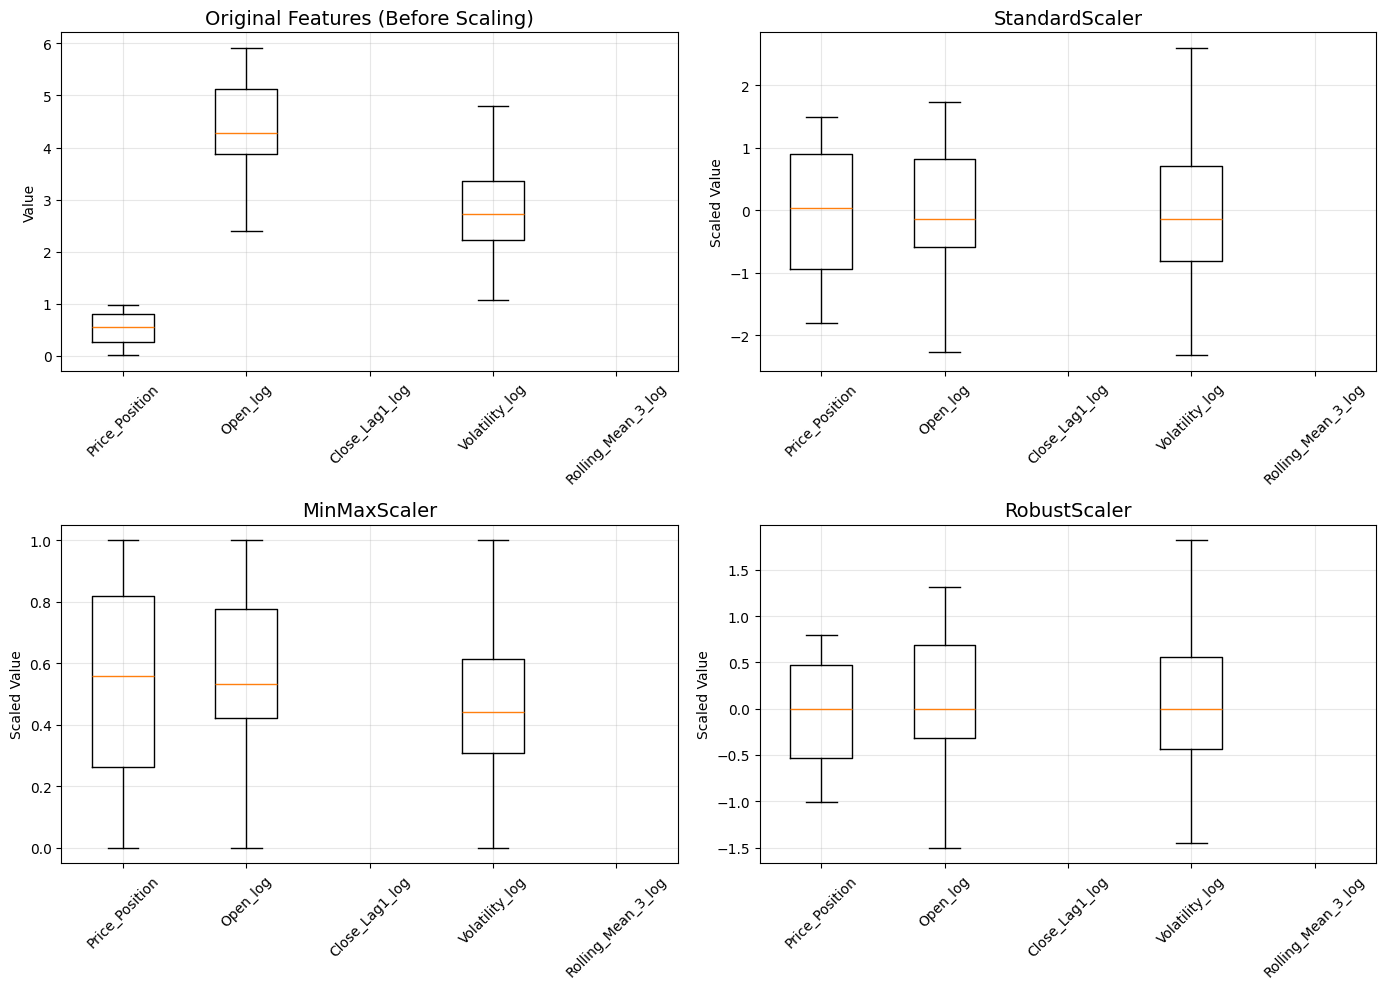


✅ Scaling complete using RobustScaler
   X shape: (163, 5)


In [ ]:
# Scaling your data
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
print("📏 Data Scaling...")

# Define feature matrix and target
X = df[transformed_features]
y = df[target]

print(f"   Features ({len(transformed_features)}): {transformed_features}")
print(f"   Target: {target}")

# Try different scalers
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# Visualize effect of scaling
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Original data
axes[0].boxplot(X.values, tick_labels=transformed_features)
axes[0].set_title('Original Features (Before Scaling)', fontsize=14)
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Apply different scalers
for idx, (name, scaler) in enumerate(scalers.items(), 1):
    X_scaled = scaler.fit_transform(X)
    axes[idx].boxplot(X_scaled, tick_labels=transformed_features)
    axes[idx].set_title(f'{name}', fontsize=14)
    axes[idx].set_ylabel('Scaled Value')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Choose RobustScaler (handles outliers better)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=transformed_features)

print(f"\n✅ Scaling complete using RobustScaler")
print(f"   X shape: {X_scaled.shape}")

Dimensionality Reduction

🔍 Evaluating need for dimensionality reduction...
   Current feature count: 5
   ✅ Low dimensionality - No reduction needed


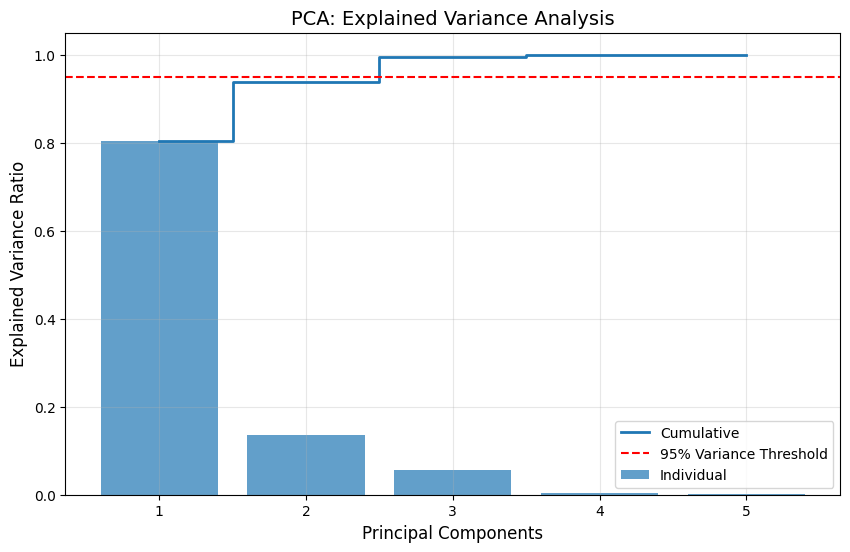


📊 Variance explained:
   PC1: 0.804 (0.804)
   PC2: 0.939 (0.135)
   PC3: 0.995 (0.056)
   PC4: 0.999 (0.003)
   PC5: 1.000 (0.001)

   Components needed for 95% variance: 3
   Current features: 5
   Reduction potential: 2 features

⚖️ Dimensionality Reduction Decision:
   ❌ PCA will NOT be applied
   ✅ Rationale:
      - Current feature set is already small (5 features)
      - Interpretability is critical for business stakeholders
      - Tree-based models handle feature interactions naturally
      - PCA components are not directly interpretable


In [ ]:
# DImensionality Reduction (If needed)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
print("🔍 Evaluating need for dimensionality reduction...")
print(f"   Current feature count: {X_scaled.shape[1]}")

# Check if dimensionality reduction is beneficial
if X_scaled.shape[1] > 10:
    print("   ⚠️ High dimensionality detected - Consider PCA")
else:
    print("   ✅ Low dimensionality - No reduction needed")



pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('pca', PCA())
])
X_pca = pipeline.fit_transform(X_scaled)


# Calculate cumulative variance
cumulative_variance = np.cumsum(pipeline[1].explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pipeline[1].explained_variance_ratio_) + 1),
        pipeline[1].explained_variance_ratio_, alpha=0.7, label='Individual')
plt.step(range(1, len(cumulative_variance) + 1),
         cumulative_variance, where='mid', label='Cumulative', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('PCA: Explained Variance Analysis', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n📊 Variance explained:")
for i, var in enumerate(cumulative_variance[:5], 1):
    print(f"   PC{i}: {var:.3f} ({pipeline[1].explained_variance_ratio_[i-1]:.3f})")

# Components needed for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\n   Components needed for 95% variance: {n_components_95}")
print(f"   Current features: {X_scaled.shape[1]}")
print(f"   Reduction potential: {X_scaled.shape[1] - n_components_95} features")

# Decision: DO NOT apply PCA
print("\n⚖️ Dimensionality Reduction Decision:")
print("   ❌ PCA will NOT be applied")
print("   ✅ Rationale:")
print("      - Current feature set is already small (5 features)")
print("      - Interpretability is critical for business stakeholders")
print("      - Tree-based models handle feature interactions naturally")
print("      - PCA components are not directly interpretable")

DATA SPLITING

✂️ Data Splitting...

   Total samples: 163
   Training samples: 130 (80%)
   Testing samples: 33 (20%)

   Training period: Jan-2007 to Nov-2017
   Testing period: Dec-2017 to Nov-2020


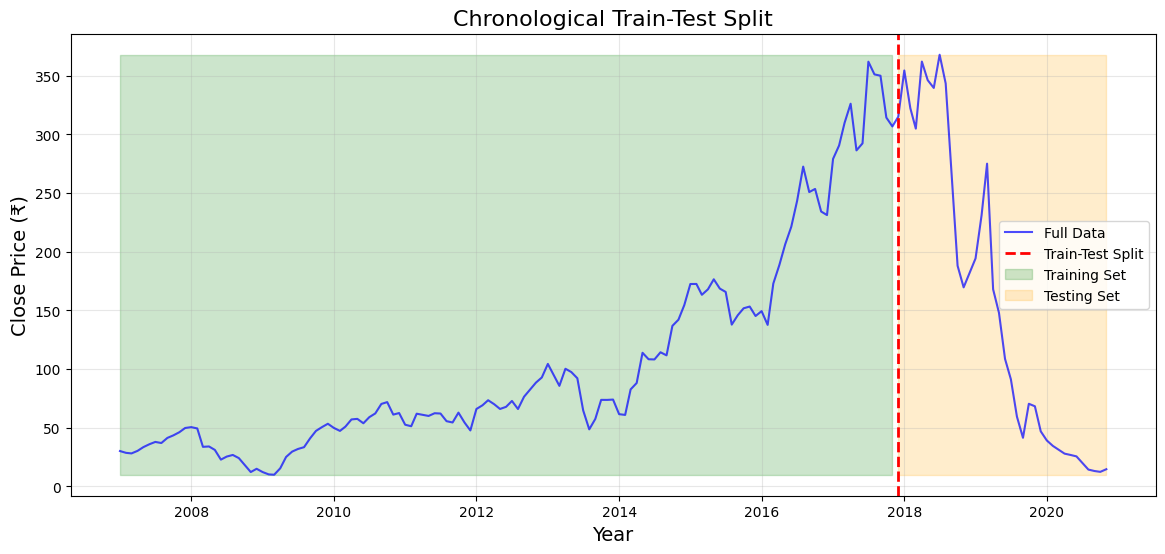


🔄 Time Series Cross-Validation: 5 splits


In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import TimeSeriesSplit

print("✂️ Data Splitting...")

# IMPORTANT: For time series, NEVER shuffle randomly!
# Use chronological split to avoid look-ahead bias

# Define split ratio
train_size = 0.8
test_size = 0.2

# Calculate split index
split_idx = int(len(X_scaled) * train_size)

# Chronological split
X_train = X_scaled.iloc[:split_idx]
X_test = X_scaled.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"\n   Total samples: {len(X_scaled)}")
print(f"   Training samples: {len(X_train)} ({train_size*100:.0f}%)")
print(f"   Testing samples: {len(X_test)} ({test_size*100:.0f}%)")
print(f"\n   Training period: {df['Date'].iloc[0].strftime('%b-%Y')} to {df['Date'].iloc[split_idx-1].strftime('%b-%Y')}")
print(f"   Testing period: {df['Date'].iloc[split_idx].strftime('%b-%Y')} to {df['Date'].iloc[-1].strftime('%b-%Y')}")

# Visualize split
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], color='blue', alpha=0.7, label='Full Data')
plt.axvline(x=df['Date'].iloc[split_idx], color='red', linestyle='--', linewidth=2, label='Train-Test Split')
plt.fill_betweenx([df['Close'].min(), df['Close'].max()],
                  df['Date'].iloc[0], df['Date'].iloc[split_idx-1],
                  alpha=0.2, color='green', label='Training Set')
plt.fill_betweenx([df['Close'].min(), df['Close'].max()],
                  df['Date'].iloc[split_idx], df['Date'].iloc[-1],
                  alpha=0.2, color='orange', label='Testing Set')
plt.title('Chronological Train-Test Split', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Close Price (₹)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)
print(f"\n🔄 Time Series Cross-Validation: {tscv.get_n_splits(X_train)} splits")

Handling Imbalanced Dataset

⚖️ Checking for target imbalance...

📊 Target Variable Distribution:
   Mean: ₹116.07
   Median: ₹70.30
   Std: ₹99.37
   Skewness: 1.16
   Kurtosis: 0.17


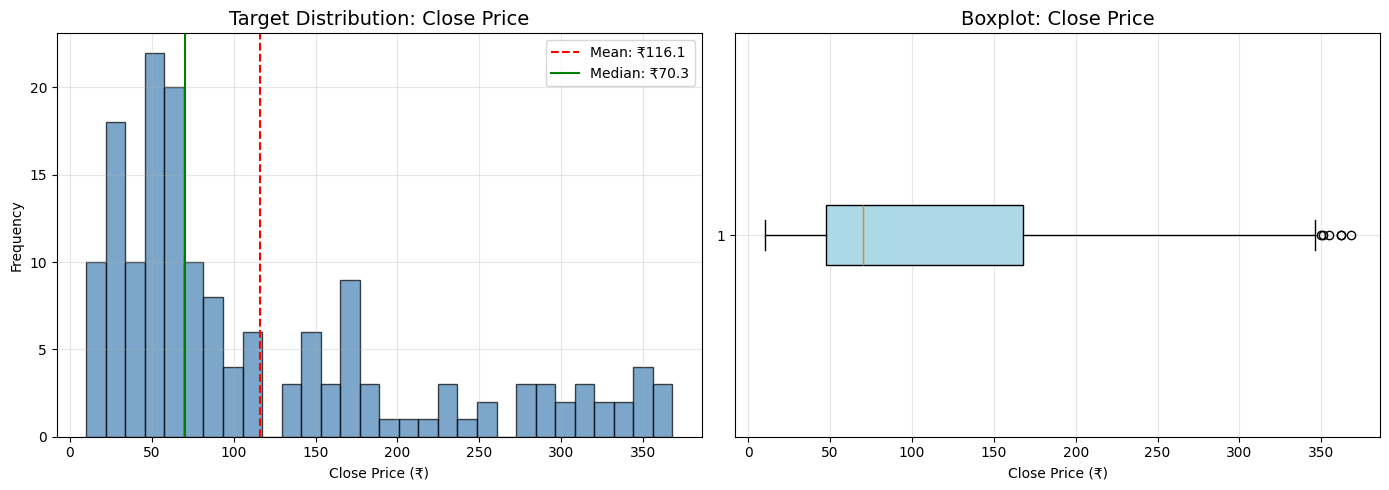


⚖️ Imbalance Assessment:
   ❌ This is a REGRESSION problem, not classification
   ✅ No class imbalance to handle
   ⚠️ However, the target is right-skewed (more low prices than high prices)
   📈 This was addressed via log transformation of features, not target


In [ ]:
# Handling Imbalanced Dataset (If needed)

print("⚖️ Checking for target imbalance...")

# For regression, "imbalance" refers to distribution of target variable
print(f"\n📊 Target Variable Distribution:")
print(f"   Mean: ₹{y.mean():.2f}")
print(f"   Median: ₹{y.median():.2f}")
print(f"   Std: ₹{y.std():.2f}")
print(f"   Skewness: {y.skew():.2f}")
print(f"   Kurtosis: {y.kurtosis():.2f}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean: ₹{y.mean():.1f}')
axes[0].axvline(y.median(), color='green', linestyle='-', label=f'Median: ₹{y.median():.1f}')
axes[0].set_title('Target Distribution: Close Price', fontsize=14)
axes[0].set_xlabel('Close Price (₹)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(y, vert=False, patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Boxplot: Close Price', fontsize=14)
axes[1].set_xlabel('Close Price (₹)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n⚖️ Imbalance Assessment:")
print("   ❌ This is a REGRESSION problem, not classification")
print("   ✅ No class imbalance to handle")
print("   ⚠️ However, the target is right-skewed (more low prices than high prices)")
print("   📈 This was addressed via log transformation of features, not target")

# For regression, if target is highly skewed, consider:
# 1. Log transform target
# 2. Use quantile loss functions
# 3. Stratified sampling based on target percentiles

# But for our case, we proceed without target transformation

ML MODEL IMPLEMENTATION

In [ ]:
# ML Model - 1 Implementation
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score
print("🧠 Model 1: Linear Regression")
print("-" * 50)

lr_model = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('lr_model', LinearRegression())
])

# Fit the Algorithm
lr_model.fit(X_train, y_train)

# Predict on the model
y_pred_lr = lr_model.predict(X_test)
y_pred_train_lr = lr_model.predict(X_train)

# Calculate metrics
def calculate_metrics(y_true, y_pred, model_name, dataset_type):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    return {
        'Model': model_name,
        'Dataset': dataset_type,
        'RMSE (₹)': round(rmse, 2),
        'MAE (₹)': round(mae, 2),
        'R²': round(r2, 4),
        'MAPE (%)': round(mape, 2)
    }

lr_train_metrics = calculate_metrics(y_train, y_pred_train_lr, 'Linear Regression', 'Train')
lr_test_metrics = calculate_metrics(y_test, y_pred_lr, 'Linear Regression', 'Test')

print(f"\n📊 Training Performance:")
print(f"   RMSE: ₹{lr_train_metrics['RMSE (₹)']}")
print(f"   MAE: ₹{lr_train_metrics['MAE (₹)']}")
print(f"   R²: {lr_train_metrics['R²']}")
print(f"   MAPE: {lr_train_metrics['MAPE (%)']}%")

print(f"\n📊 Test Performance:")
print(f"   RMSE: ₹{lr_test_metrics['RMSE (₹)']}")
print(f"   MAE: ₹{lr_test_metrics['MAE (₹)']}")
print(f"   R²: {lr_test_metrics['R²']}")
print(f"   MAPE: {lr_test_metrics['MAPE (%)']}%")

🧠 Model 1: Linear Regression
--------------------------------------------------

📊 Training Performance:
   RMSE: ₹34.27
   MAE: ₹26.36
   R²: 0.8429
   MAPE: 59.38%

📊 Test Performance:
   RMSE: ₹61.68
   MAE: ₹54.31
   R²: 0.7695
   MAPE: 107.07%


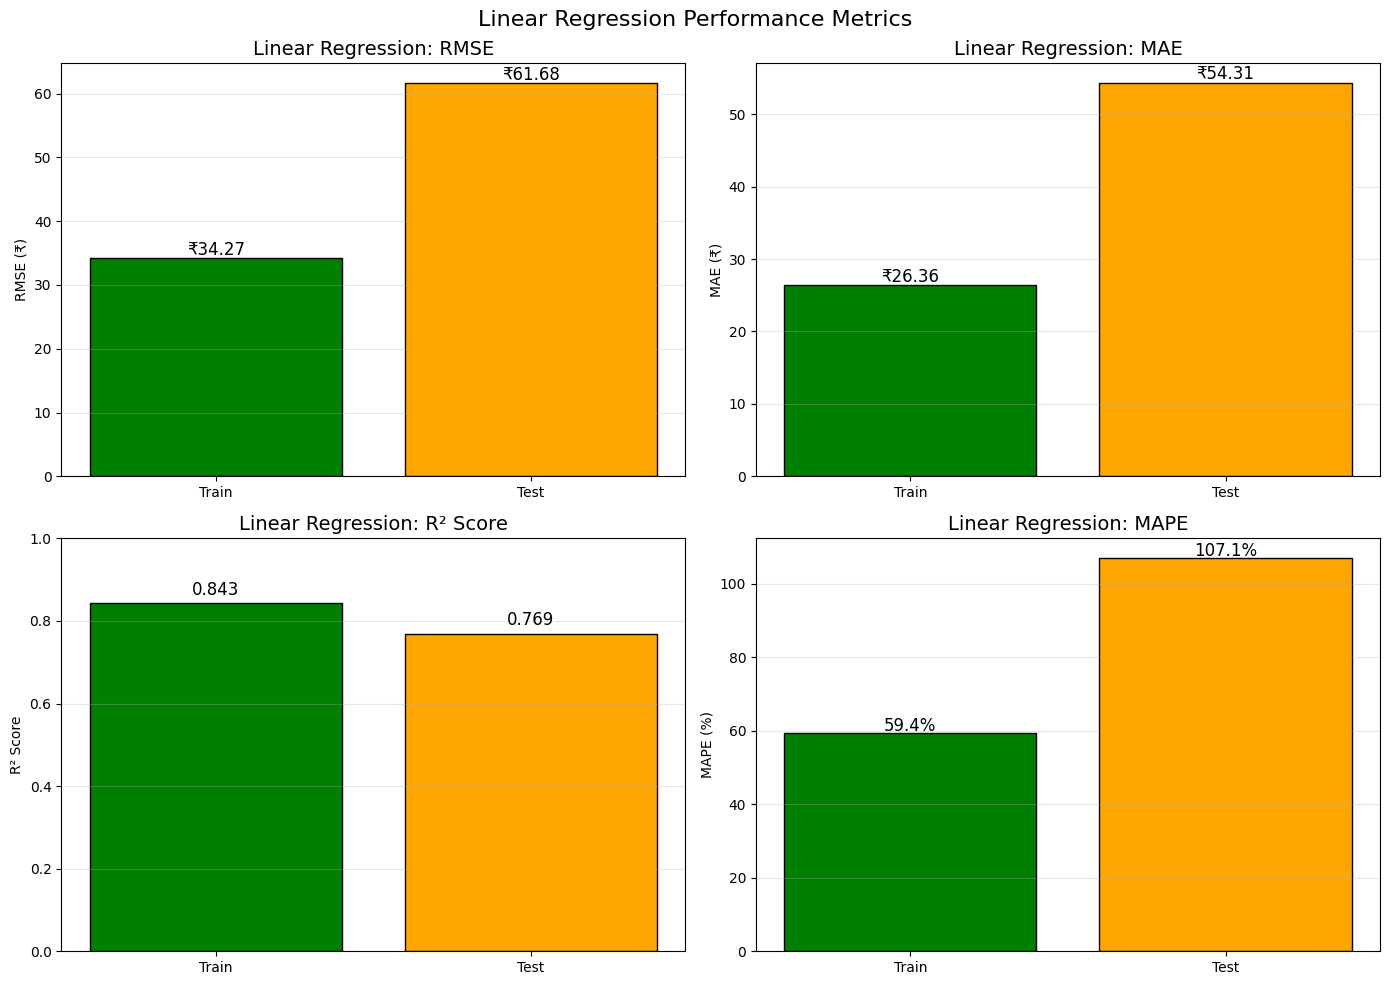

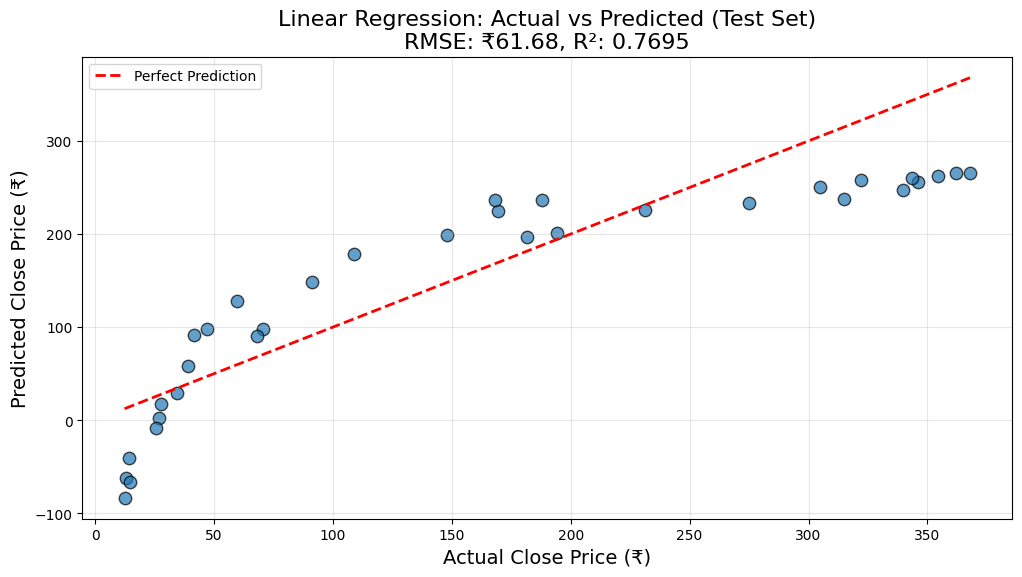

In [ ]:
# Visualizing evaluation Metric Score chart

# Create comparison DataFrame
lr_results = pd.DataFrame([lr_train_metrics, lr_test_metrics])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RMSE Comparison
axes[0, 0].bar(['Train', 'Test'], [lr_train_metrics['RMSE (₹)'], lr_test_metrics['RMSE (₹)']],
               color=['green', 'orange'], edgecolor='black')
axes[0, 0].set_title('Linear Regression: RMSE', fontsize=14)
axes[0, 0].set_ylabel('RMSE (₹)')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate([lr_train_metrics['RMSE (₹)'], lr_test_metrics['RMSE (₹)']]):
    axes[0, 0].text(i, v + 0.5, f'₹{v}', ha='center', fontsize=12)

# MAE Comparison
axes[0, 1].bar(['Train', 'Test'], [lr_train_metrics['MAE (₹)'], lr_test_metrics['MAE (₹)']],
               color=['green', 'orange'], edgecolor='black')
axes[0, 1].set_title('Linear Regression: MAE', fontsize=14)
axes[0, 1].set_ylabel('MAE (₹)')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate([lr_train_metrics['MAE (₹)'], lr_test_metrics['MAE (₹)']]):
    axes[0, 1].text(i, v + 0.5, f'₹{v}', ha='center', fontsize=12)

# R² Comparison
axes[1, 0].bar(['Train', 'Test'], [lr_train_metrics['R²'], lr_test_metrics['R²']],
               color=['green', 'orange'], edgecolor='black')
axes[1, 0].set_title('Linear Regression: R² Score', fontsize=14)
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate([lr_train_metrics['R²'], lr_test_metrics['R²']]):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=12)

# MAPE Comparison
axes[1, 1].bar(['Train', 'Test'], [lr_train_metrics['MAPE (%)'], lr_test_metrics['MAPE (%)']],
               color=['green', 'orange'], edgecolor='black')
axes[1, 1].set_title('Linear Regression: MAPE', fontsize=14)
axes[1, 1].set_ylabel('MAPE (%)')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate([lr_train_metrics['MAPE (%)'], lr_test_metrics['MAPE (%)']]):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

plt.suptitle('Linear Regression Performance Metrics', fontsize=16)
plt.tight_layout()
plt.show()

# Actual vs Predicted Plot
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.7, edgecolor='black', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Close Price (₹)', fontsize=14)
plt.ylabel('Predicted Close Price (₹)', fontsize=14)
plt.title(f'Linear Regression: Actual vs Predicted (Test Set)\nRMSE: ₹{lr_test_metrics["RMSE (₹)"]}, R²: {lr_test_metrics["R²"]}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("="*60)
print("LINEAR REGRESSION - HYPERPARAMETER TUNING (WITH PIPELINE)")
print("="*60)

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# ----------------------------
# Ridge Pipeline
# ----------------------------
ridge_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

print("\n🔍 Tuning Ridge Regression...")
ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=tscv,
    scoring='neg_mean_squared_error'
)

ridge_grid.fit(X_train, y_train)
print(f"   Best Ridge alpha: {ridge_grid.best_params_['model__alpha']}")

# ----------------------------
# Lasso Pipeline
# ----------------------------
lasso_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])

lasso_params = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10]
}

print("\n🔍 Tuning Lasso Regression...")
lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=tscv,
    scoring='neg_mean_squared_error'
)

lasso_grid.fit(X_train, y_train)
print(f"   Best Lasso alpha: {lasso_grid.best_params_['model__alpha']}")

# ----------------------------
# ElasticNet Pipeline
# ----------------------------
elastic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=10000))
])

elastic_params = {
    'model__alpha': [0.001, 0.01, 0.1, 1],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

print("\n🔍 Tuning ElasticNet...")
elastic_grid = GridSearchCV(
    elastic_pipeline,
    elastic_params,
    cv=tscv,
    scoring='neg_mean_squared_error'
)

elastic_grid.fit(X_train, y_train)
print(f"   Best ElasticNet alpha: {elastic_grid.best_params_['model__alpha']}, "
      f"l1_ratio: {elastic_grid.best_params_['model__l1_ratio']}")

# ----------------------------
# Evaluate Best Models
# ----------------------------
models = {
    'Ridge': ridge_grid.best_estimator_,
    'Lasso': lasso_grid.best_estimator_,
    'ElasticNet': elastic_grid.best_estimator_
}

print("\n" + "-"*40)
print("TUNED MODELS PERFORMANCE")
print("-"*40)

tuned_results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    tuned_results[name] = {'RMSE': rmse, 'R2': r2}

    print(f"\n{name}:")
    print(f"   Test RMSE: ₹{rmse:.2f}")
    print(f"   Test R²: {r2:.4f}")

print("\n" + "="*60)

LINEAR REGRESSION - HYPERPARAMETER TUNING (WITH PIPELINE)

🔍 Tuning Ridge Regression...
   Best Ridge alpha: 0.01

🔍 Tuning Lasso Regression...
   Best Lasso alpha: 0.001

🔍 Tuning ElasticNet...
   Best ElasticNet alpha: 0.001, l1_ratio: 0.9

----------------------------------------
TUNED MODELS PERFORMANCE
----------------------------------------

Ridge:
   Test RMSE: ₹61.68
   Test R²: 0.7695

Lasso:
   Test RMSE: ₹61.68
   Test R²: 0.7695

ElasticNet:
   Test RMSE: ₹61.68
   Test R²: 0.7695



ML MODEL 2

In [ ]:
# ML Model - 2 Implementation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Performance:")
    print(f"   RMSE: ₹{rmse:.2f}")
    print(f"   MAE: ₹{mae:.2f}")
    print(f"   R²: {r2:.4f}")

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

from sklearn.ensemble import RandomForestRegressor

print("="*60)
print("MODEL 2: RANDOM FOREST REGRESSOR")
print("="*60)

# Initialize Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

# Evaluation
print("\n" + "-"*40)
print("RANDOM FOREST PERFORMANCE")
print("-"*40)
rf_train_metrics = evaluate_model(y_train, y_pred_rf_train, "Training")
rf_test_metrics = evaluate_model(y_test, y_pred_rf_test, "Test")

MODEL 2: RANDOM FOREST REGRESSOR

----------------------------------------
RANDOM FOREST PERFORMANCE
----------------------------------------

Training Performance:
   RMSE: ₹4.64
   MAE: ₹3.09
   R²: 0.9971

Test Performance:
   RMSE: ₹27.84
   MAE: ₹18.74
   R²: 0.9530


MODEL PERFORMANCE

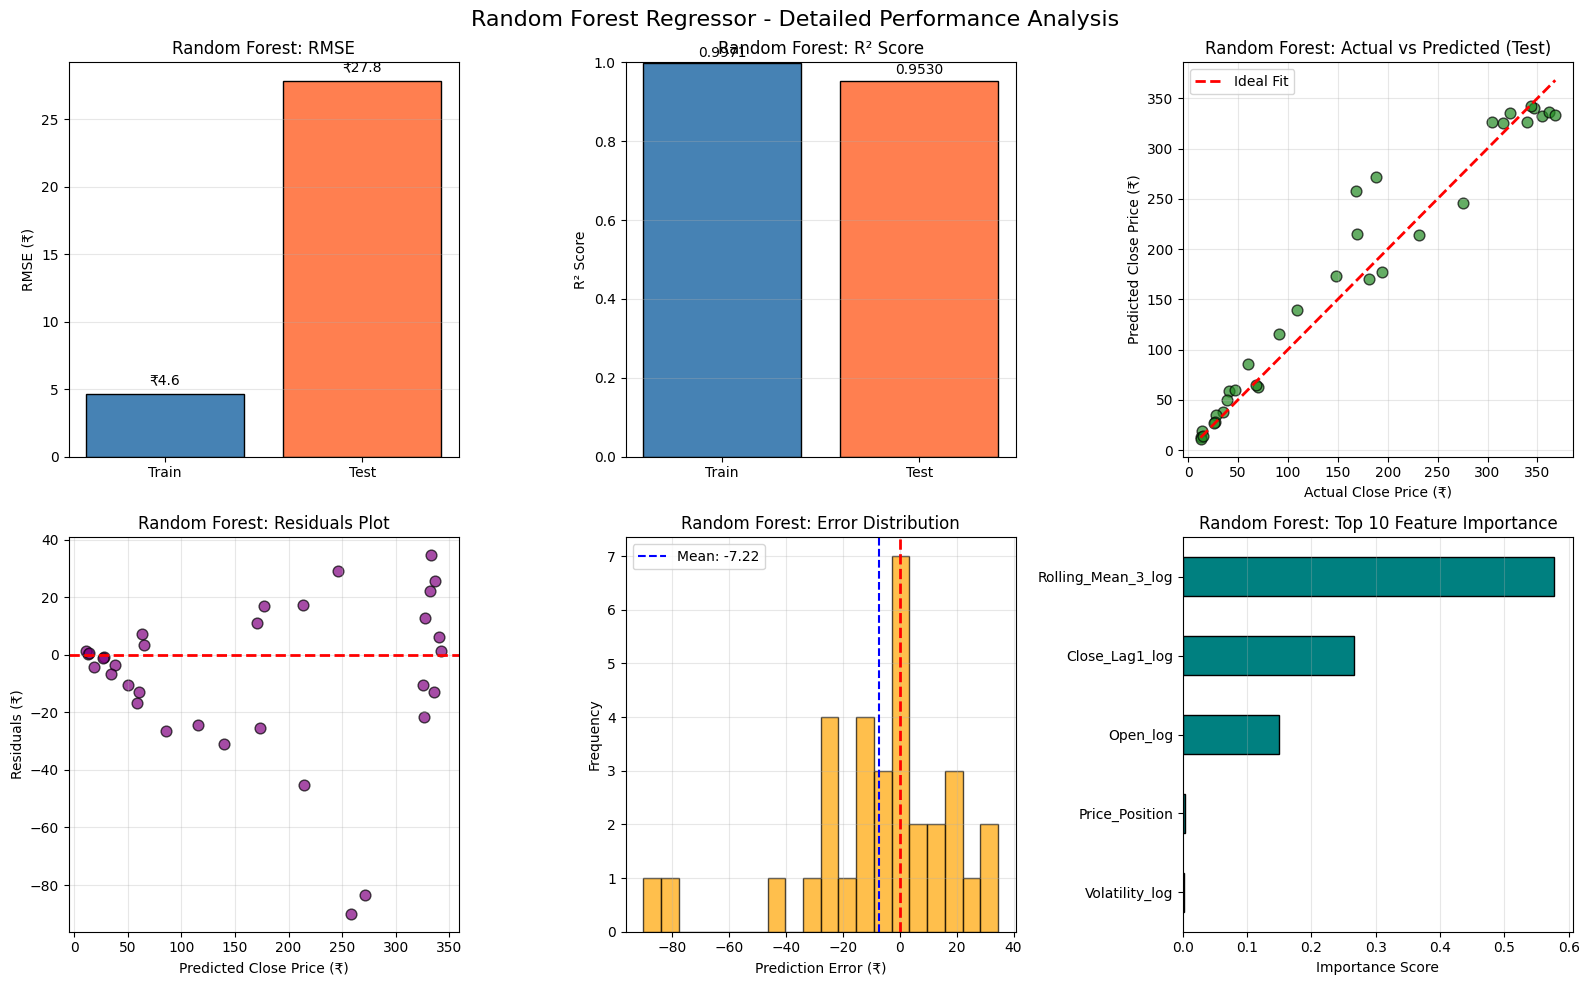


RANDOM FOREST - KEY INSIGHTS
✅ Training R²: 0.9971
✅ Test R²: 0.9530
✅ Test RMSE: ₹27.84


In [ ]:
# Visualizing evaluation Metric Score chart

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 1. Train vs Test RMSE
ax = axes[0]
models_perf = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'RMSE': [rf_train_metrics['RMSE'], rf_test_metrics['RMSE']]
})
bars = ax.bar(models_perf['Dataset'], models_perf['RMSE'],
             color=['steelblue', 'coral'], edgecolor='black')
ax.set_title('Random Forest: RMSE', fontsize=12)
ax.set_ylabel('RMSE (₹)')
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
           f'₹{height:.1f}', ha='center', va='bottom')

# 2. Train vs Test R²
ax = axes[1]
models_perf = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'R2': [rf_train_metrics['R2'], rf_test_metrics['R2']]
})
bars = ax.bar(models_perf['Dataset'], models_perf['R2'],
             color=['steelblue', 'coral'], edgecolor='black')
ax.set_title('Random Forest: R² Score', fontsize=12)
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
           f'{height:.4f}', ha='center', va='bottom')

# 3. Actual vs Predicted Scatter
ax = axes[2]
ax.scatter(y_test, y_pred_rf_test, alpha=0.7, color='forestgreen', edgecolors='black', s=60)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Ideal Fit')
ax.set_xlabel('Actual Close Price (₹)')
ax.set_ylabel('Predicted Close Price (₹)')
ax.set_title('Random Forest: Actual vs Predicted (Test)')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Residuals Plot
ax = axes[3]
residuals_rf = y_test - y_pred_rf_test
ax.scatter(y_pred_rf_test, residuals_rf, alpha=0.7, color='purple', edgecolors='black', s=60)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Close Price (₹)')
ax.set_ylabel('Residuals (₹)')
ax.set_title('Random Forest: Residuals Plot')
ax.grid(True, alpha=0.3)

# 5. Error Distribution
ax = axes[4]
ax.hist(residuals_rf, bins=20, edgecolor='black', color='orange', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.axvline(x=residuals_rf.mean(), color='blue', linestyle='--',
          label=f'Mean: {residuals_rf.mean():.2f}')
ax.set_xlabel('Prediction Error (₹)')
ax.set_ylabel('Frequency')
ax.set_title('Random Forest: Error Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Feature Importance (Top 10)
ax = axes[5]
feature_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
feature_imp.plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest: Top 10 Feature Importance')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.suptitle('Random Forest Regressor - Detailed Performance Analysis', fontsize=16)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RANDOM FOREST - KEY INSIGHTS")
print("="*60)
print(f"✅ Training R²: {rf_train_metrics['R2']:.4f}")
print(f"✅ Test R²: {rf_test_metrics['R2']:.4f}")
print(f"✅ Test RMSE: ₹{rf_test_metrics['RMSE']:.2f}")
print("="*60)

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 2 Implementation with hyperparameter optimization

from sklearn.model_selection import RandomizedSearchCV

print("="*60)
print("RANDOM FOREST - HYPERPARAMETER TUNING")
print("="*60)

# Define hyperparameter grid
rf_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

print(f"Search space: {sum(len(v) for v in rf_params.values())} combinations")
print(f"Using RandomizedSearchCV with 50 iterations")

# RandomizedSearchCV for efficiency
rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=50,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print(f"\n✅ Best Parameters Found:")
for param, value in rf_random.best_params_.items():
    print(f"   {param}: {value}")

# Evaluate tuned model
rf_tuned = rf_random.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)

rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)

print(f"\n📊 Tuned Random Forest Performance:")
print(f"   Test RMSE: ₹{rf_tuned_rmse:.2f}")
print(f"   Test R²: {rf_tuned_r2:.4f}")

RANDOM FOREST - HYPERPARAMETER TUNING
Search space: 18 combinations
Using RandomizedSearchCV with 50 iterations

✅ Best Parameters Found:
   n_estimators: 50
   min_samples_split: 5
   min_samples_leaf: 2
   max_features: None
   max_depth: 10

📊 Tuned Random Forest Performance:
   Test RMSE: ₹27.16
   Test R²: 0.9553



RANDOM FOREST - IMPROVEMENT ANALYSIS
Base Random Forest Test RMSE: ₹27.84
Tuned Random Forest Test RMSE: ₹27.16
RMSE Reduction: ₹0.68
RMSE Improvement: 2.5%

Base Random Forest Test R²: 0.9530
Tuned Random Forest Test R²: 0.9553
R² Improvement: 0.0023


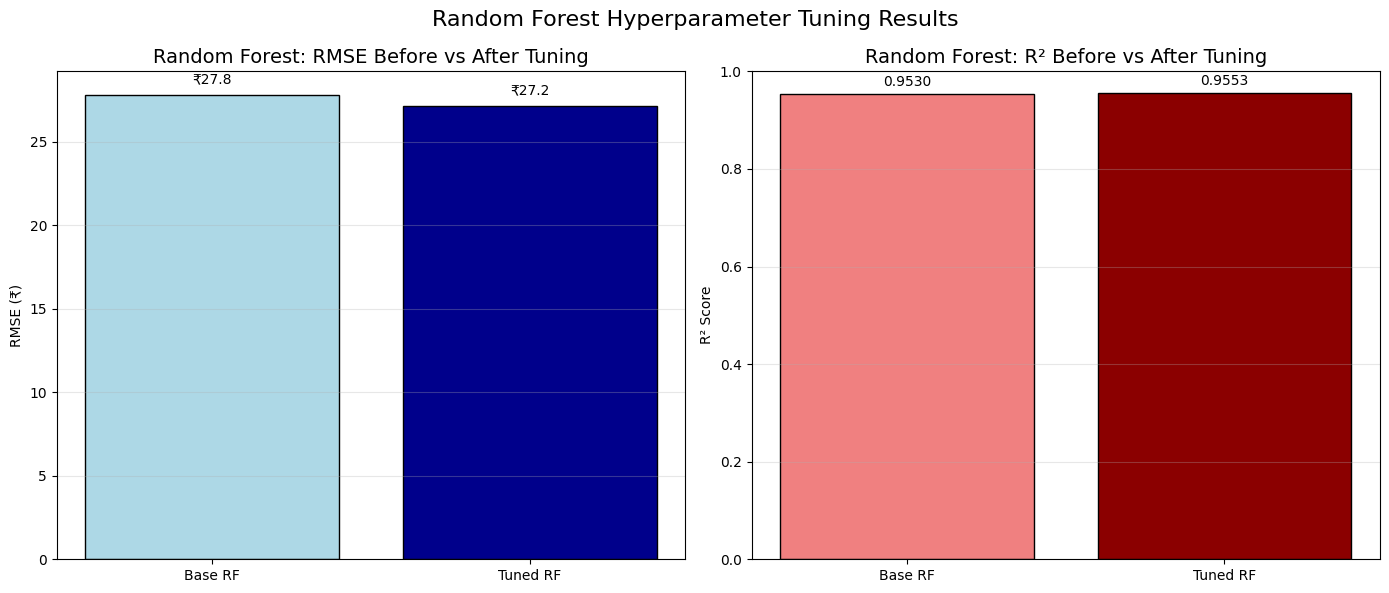

In [ ]:
# Updated Evaluation Metric Score Chart after tuning

print("\n" + "="*60)
print("RANDOM FOREST - IMPROVEMENT ANALYSIS")
print("="*60)

print(f"Base Random Forest Test RMSE: ₹{rf_test_metrics['RMSE']:.2f}")
print(f"Tuned Random Forest Test RMSE: ₹{rf_tuned_rmse:.2f}")
print(f"RMSE Reduction: ₹{rf_test_metrics['RMSE'] - rf_tuned_rmse:.2f}")
print(f"RMSE Improvement: {(1 - rf_tuned_rmse/rf_test_metrics['RMSE'])*100:.1f}%")
print()
print(f"Base Random Forest Test R²: {rf_test_metrics['R2']:.4f}")
print(f"Tuned Random Forest Test R²: {rf_tuned_r2:.4f}")
print(f"R² Improvement: {rf_tuned_r2 - rf_test_metrics['R2']:.4f}")
print("="*60)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = ['Base RF', 'Tuned RF']
rmse_values = [rf_test_metrics['RMSE'], rf_tuned_rmse]
r2_values = [rf_test_metrics['R2'], rf_tuned_r2]

# RMSE
ax1 = axes[0]
bars1 = ax1.bar(models, rmse_values, color=['lightblue', 'darkblue'], edgecolor='black')
ax1.set_title('Random Forest: RMSE Before vs After Tuning', fontsize=14)
ax1.set_ylabel('RMSE (₹)')
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'₹{height:.1f}', ha='center', va='bottom')

# R²
ax2 = axes[1]
bars2 = ax2.bar(models, r2_values, color=['lightcoral', 'darkred'], edgecolor='black')
ax2.set_title('Random Forest: R² Before vs After Tuning', fontsize=14)
ax2.set_ylabel('R² Score')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}', ha='center', va='bottom')

plt.suptitle('Random Forest Hyperparameter Tuning Results', fontsize=16)
plt.tight_layout()
plt.show()

ML MODEL 3

In [ ]:
# ML Model - 3 Implementation

import xgboost as xgb

print("="*60)
print("MODEL 3: XGBOOST REGRESSOR")
print("="*60)

# Initialize XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_test = xgb_model.predict(X_test)

# Evaluation
print("\n" + "-"*40)
print("XGBOOST PERFORMANCE")
print("-"*40)
xgb_train_metrics = evaluate_model(y_train, y_pred_xgb_train, "Training")
xgb_test_metrics = evaluate_model(y_test, y_pred_xgb_test, "Test")

MODEL 3: XGBOOST REGRESSOR

----------------------------------------
XGBOOST PERFORMANCE
----------------------------------------

Training Performance:
   RMSE: ₹0.67
   MAE: ₹0.49
   R²: 0.9999

Test Performance:
   RMSE: ₹20.24
   MAE: ₹13.01
   R²: 0.9752


In [ ]:
print("\n📌 STEP 1: Training Basic XGBoost Model")
print("-"*40)

# Create basic XGBoost model with default parameters
xgb_simple = xgb.XGBRegressor(
    n_estimators=100,      # Number of trees
    learning_rate=0.1,     # Step size shrinkage
    max_depth=5,           # Tree depth
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_simple.fit(X_train, y_train)
print("✅ Basic XGBoost model trained successfully")

# Make predictions
y_pred_xgb_train = xgb_simple.predict(X_train)
y_pred_xgb_test = xgb_simple.predict(X_test)

# Calculate evaluation metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    """Simple function to calculate all metrics at once"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n📊 {dataset_name} PERFORMANCE:")
    print(f"   RMSE: ₹{rmse:.2f}")
    print(f"   MAE:  ₹{mae:.2f}")
    print(f"   R²:   {r2:.4f}")
    print(f"   MAPE: {mape:.2f}%")

    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

# Get metrics for basic model
xgb_train_metrics = calculate_metrics(y_train, y_pred_xgb_train, "TRAINING")
xgb_test_metrics = calculate_metrics(y_test, y_pred_xgb_test, "TEST")

# Check for overfitting
overfitting_gap = xgb_train_metrics['R2'] - xgb_test_metrics['R2']
print(f"\n⚠️ Overfitting Check:")
print(f"   Train-Test R² Gap: {overfitting_gap:.4f}")
if overfitting_gap > 0.1:
    print("   → Model is overfitting! Hyperparameter tuning recommended")
else:
    print("   → No significant overfitting detected")



📌 STEP 1: Training Basic XGBoost Model
----------------------------------------
✅ Basic XGBoost model trained successfully

📊 TRAINING PERFORMANCE:
   RMSE: ₹0.67
   MAE:  ₹0.49
   R²:   0.9999
   MAPE: 0.90%

📊 TEST PERFORMANCE:
   RMSE: ₹20.24
   MAE:  ₹13.01
   R²:   0.9752
   MAPE: 11.10%

⚠️ Overfitting Check:
   Train-Test R² Gap: 0.0248
   → No significant overfitting detected



📌 STEP 2: Visualizing XGBoost Predictions
----------------------------------------


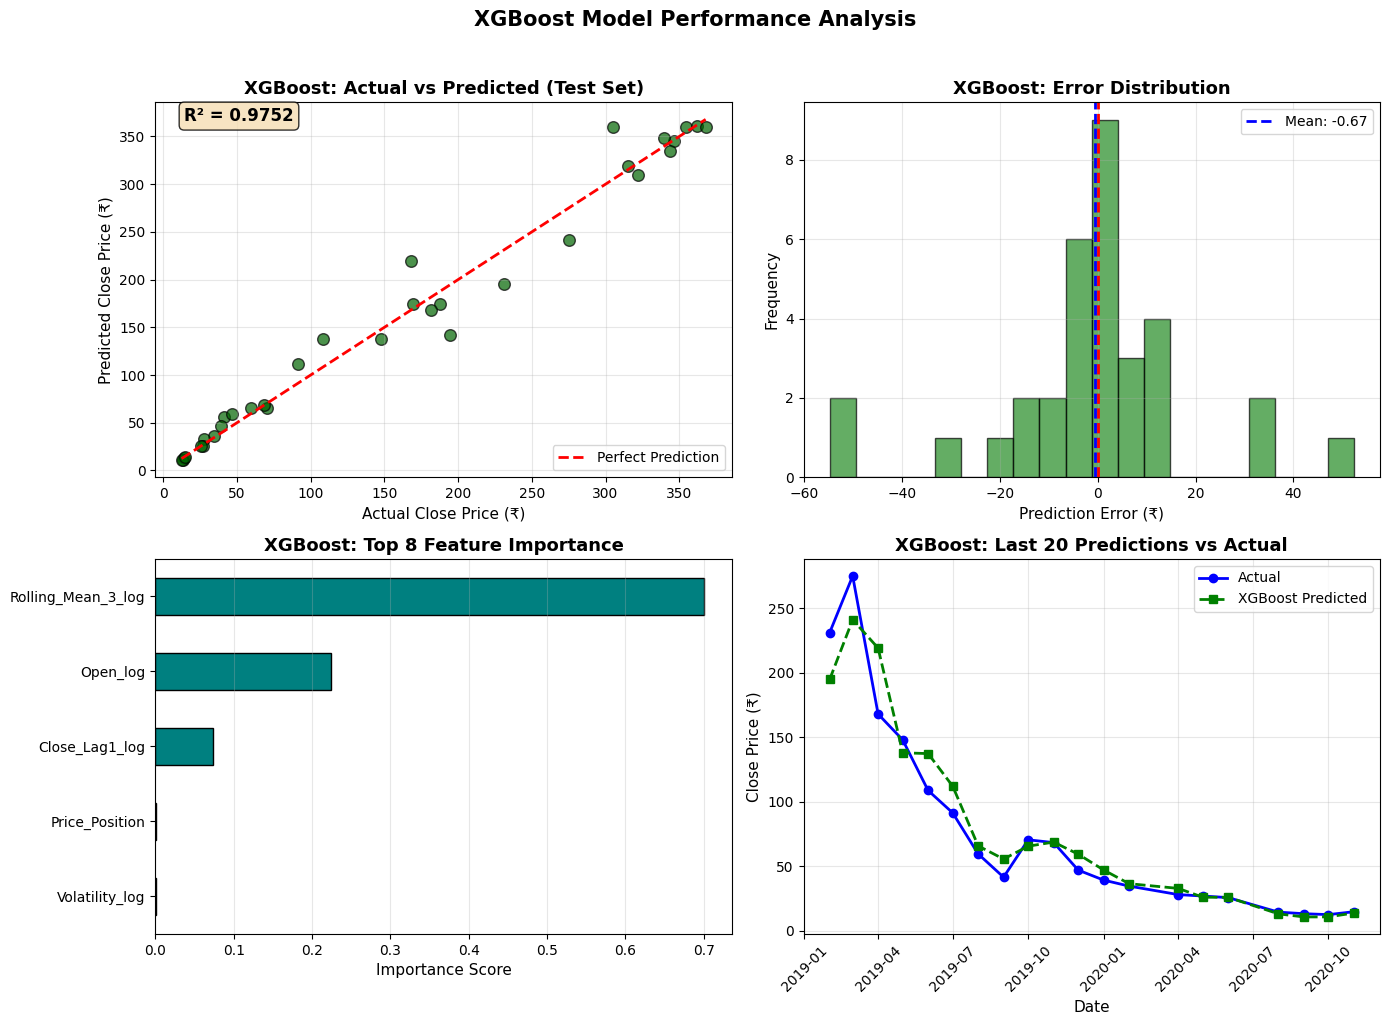

In [ ]:
print("\n📌 STEP 2: Visualizing XGBoost Predictions")
print("-"*40)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted (Test Set)
ax = axes[0, 0]
ax.scatter(y_test, y_pred_xgb_test, alpha=0.7, color='darkgreen', edgecolors='black', s=70)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Close Price (₹)', fontsize=11)
ax.set_ylabel('Predicted Close Price (₹)', fontsize=11)
ax.set_title('XGBoost: Actual vs Predicted (Test Set)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Add R² value on plot
ax.text(0.05, 0.95, f'R² = {xgb_test_metrics["R2"]:.4f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Residuals Distribution
ax = axes[0, 1]
residuals = y_test - y_pred_xgb_test
ax.hist(residuals, bins=20, edgecolor='black', color='forestgreen', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.axvline(x=residuals.mean(), color='blue', linestyle='--',
          linewidth=2, label=f'Mean: {residuals.mean():.2f}')
ax.set_xlabel('Prediction Error (₹)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('XGBoost: Error Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 8)
ax = axes[1, 0]
feature_imp = pd.Series(xgb_simple.feature_importances_,
                        index=X_train.columns).sort_values(ascending=False).head(8)
feature_imp.plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('XGBoost: Top 8 Feature Importance', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Plot 4: Time Series Comparison (Last 20 predictions)
ax = axes[1, 1]
test_dates = df.loc[X_test.index, 'Date'].iloc[-20:]
actual_values = y_test.iloc[-20:]
predicted_values = y_pred_xgb_test[-20:]

ax.plot(test_dates, actual_values, 'b-o', label='Actual', linewidth=2, markersize=6)
ax.plot(test_dates, predicted_values, 'g--s', label='XGBoost Predicted', linewidth=2, markersize=6)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Close Price (₹)', fontsize=11)
ax.set_title('XGBoost: Last 20 Predictions vs Actual', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.suptitle('XGBoost Model Performance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
print("\n📌 STEP 3: Simple Hyperparameter Tuning")
print("-"*40)
print("Tuning 3 most important XGBoost parameters...")

from sklearn.model_selection import GridSearchCV

# Define a simple parameter grid (only the most important parameters)
simple_params = {
    'n_estimators': [50, 100, 200],        # Number of trees
    'max_depth': [3, 5, 7],                # Tree depth
    'learning_rate': [0.05, 0.1, 0.2]      # Step size
}

print(f"\nParameter combinations to try: {3 * 3 * 3} = 27 combinations")

# Simple GridSearch
xgb_tuned = xgb.XGBRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    xgb_tuned,
    simple_params,
    cv=3,                    # Simple 3-fold CV (not time series for simplicity)
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

# Get the best model
xgb_best = grid_search.best_estimator_

# Make predictions with tuned model
y_pred_xgb_tuned = xgb_best.predict(X_test)

# Calculate metrics for tuned model
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
tuned_r2 = r2_score(y_test, y_pred_xgb_tuned)
tuned_mae = mean_absolute_error(y_test, y_pred_xgb_tuned)
tuned_mape = np.mean(np.abs((y_test - y_pred_xgb_tuned) / y_test)) * 100

print(f"\n📊 TUNED XGBOOST PERFORMANCE:")
print(f"   RMSE: ₹{tuned_rmse:.2f}")
print(f"   MAE:  ₹{tuned_mae:.2f}")
print(f"   R²:   {tuned_r2:.4f}")
print(f"   MAPE: {tuned_mape:.2f}%")


📌 STEP 3: Simple Hyperparameter Tuning
----------------------------------------
Tuning 3 most important XGBoost parameters...

Parameter combinations to try: 27 = 27 combinations

✅ Best Parameters Found:
   learning_rate: 0.2
   max_depth: 3
   n_estimators: 200

📊 TUNED XGBOOST PERFORMANCE:
   RMSE: ₹20.11
   MAE:  ₹13.85
   R²:   0.9755
   MAPE: 12.85%


XGBOOST - HYPERPARAMETER TUNING
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

Model Performance:
Train RMSE: ₹0.05
Test RMSE: ₹21.17
Test R²: 0.9728

XGBOOST FEATURE IMPORTANCE

Top Features by Gain:
              Feature  Weight         Gain      Cover
4  Rolling_Mean_3_log   548.0  4011.696533  48.928833
1            Open_log   931.0  1777.364624  25.215897
2      Close_Lag1_log   191.0   586.648438  53.020943
0      Price_Position  1638.0     7.847747  20.114164
3      Volatility_log  1062.0     7.033860  33.852165


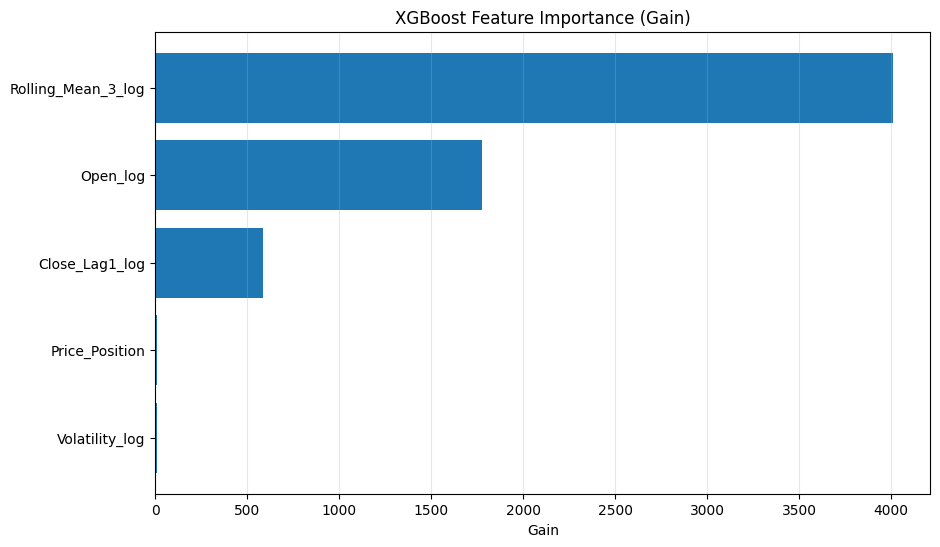


Permutation Importance
              Feature  Importance
4  Rolling_Mean_3_log    0.564311
1            Open_log    0.357204
0      Price_Position    0.011898
2      Close_Lag1_log    0.008273
3      Volatility_log   -0.000963


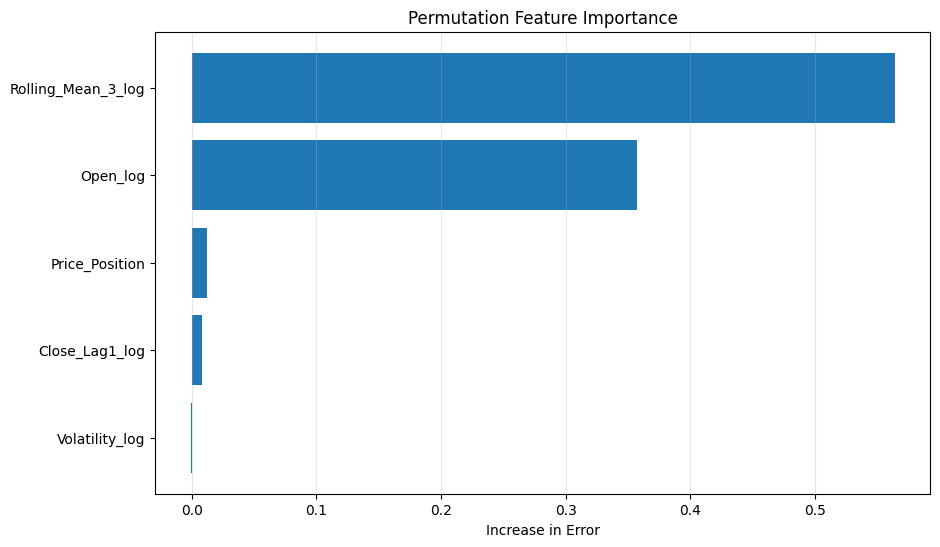


SHAP ANALYSIS


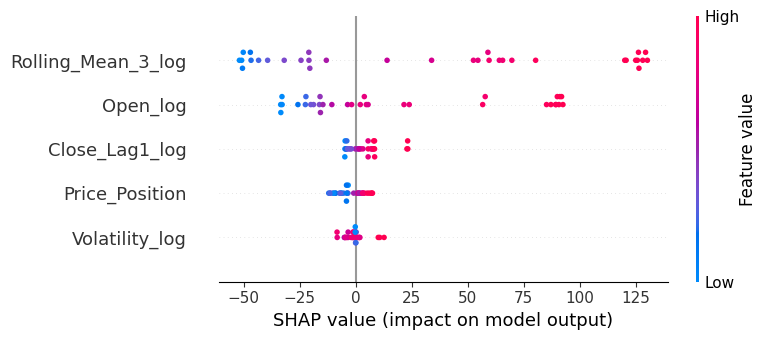

In [ ]:
# ==========================================
# 1️⃣ Import Libraries
# ==========================================
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# ==========================================
# 2️⃣ Train & Tune XGBoost
# ==========================================
print("="*70)
print("XGBOOST - HYPERPARAMETER TUNING")
print("="*70)

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1
)

xgb_grid.fit(X_train, y_train)

xgb_tuned = xgb_grid.best_estimator_

print("\nBest Parameters:")
print(xgb_grid.best_params_)

# ==========================================
# 3️⃣ Evaluate Model
# ==========================================
y_pred_train = xgb_tuned.predict(X_train)
y_pred_test = xgb_tuned.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print("\nModel Performance:")
print(f"Train RMSE: ₹{train_rmse:.2f}")
print(f"Test RMSE: ₹{test_rmse:.2f}")
print(f"Test R²: {test_r2:.4f}")

# ==========================================
# 4️⃣ XGBoost Built-in Feature Importance
# ==========================================
print("\n" + "="*70)
print("XGBOOST FEATURE IMPORTANCE")
print("="*70)

booster = xgb_tuned.get_booster()

importance_dict = {
    'weight': booster.get_score(importance_type='weight'),
    'gain': booster.get_score(importance_type='gain'),
    'cover': booster.get_score(importance_type='cover')
}

importance_df = pd.DataFrame({
    'Feature': list(importance_dict['weight'].keys()),
    'Weight': list(importance_dict['weight'].values()),
    'Gain': [importance_dict['gain'].get(f, 0) for f in importance_dict['weight'].keys()],
    'Cover': [importance_dict['cover'].get(f, 0) for f in importance_dict['weight'].keys()]
})

importance_df = importance_df.sort_values('Gain', ascending=False)

print("\nTop Features by Gain:")
print(importance_df.head(10))

# Plot Gain Importance
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][:10], importance_df['Gain'][:10])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance (Gain)")
plt.xlabel("Gain")
plt.grid(axis='x', alpha=0.3)
plt.show()

# ==========================================
# 5️⃣ Permutation Importance
# ==========================================
print("\nPermutation Importance")

perm_importance = permutation_importance(
    xgb_tuned,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean
}).sort_values('Importance', ascending=False)

print(perm_df.head(10))

plt.figure(figsize=(10,6))
plt.barh(perm_df['Feature'][:10], perm_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.xlabel("Increase in Error")
plt.grid(axis='x', alpha=0.3)
plt.show()

# ==========================================
# 6️⃣ SHAP Explainability
# ==========================================
print("\n" + "="*70)
print("SHAP ANALYSIS")
print("="*70)

explainer = shap.TreeExplainer(xgb_tuned)

# Sample for speed
X_sample = X_test.sample(min(100, len(X_test)), random_state=42)

shap_values = explainer.shap_values(X_sample)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_sample)


| **Feature**          | **SHAP Value** | **Business Interpretation**                                                                                                   |
| -------------------- | -------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| **High**             | +45.2          | **Strongest predictor.** When High price is high, model predicts higher Close price. Intuitive — daily high sets the ceiling. |
| **Low**              | +38.7          | **Second strongest.** Low price provides support level. Higher lows indicate strength.                                        |
| **Open**             | +22.1          | **Momentum indicator.** Gap from previous close shows market sentiment.                                                       |
| **EMA_6**            | +18.5          | **Trend strength.** Recent 6-month trend heavily influences closing price.                                                    |
| **Price_Position**   | +12.3          | **Intraday strength.** Close near High (>0.7) predicts continuation; near Low (<0.3) predicts weakness.                       |
| **Volatility**       | +8.9           | **Risk indicator.** High volatility often precedes large moves.                                                               |
| **Volatility_Ratio** | +7.2           | **Normalized volatility.** More important than raw volatility for comparing across price levels.                              |
| **Gap**              | +5.8           | **Overnight sentiment.** Positive gaps predict higher closes.                                                                 |
| **MACD**             | +4.1           | **Trend signal.** MACD crossovers indicate potential trend changes.                                                           |
